# 🔍 Agent Pipeline Evaluation Dashboard

Loads all `*_node_activity.json` files from `output/results/` and produces clean, scalable visualisations that stay readable regardless of how many log files are present.

---

In [12]:
import json, re, glob, warnings
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
})

NODE_COLORS = {
    "match_schemas":        "#2ecc71",
    "profile_data":         "#27ae60",
    "run_blocking_tester":  "#1abc9c",
    "run_matching_tester":  "#16a085",
    "pipeline_adaption":    "#f39c12",
    "execute_pipeline":     "#3498db",
    "evaluation_adaption":  "#e67e22",
    "execute_evaluation":   "#2980b9",
    "evaluation_decision":  "#9b59b6",
    "evaluation_reasoning": "#8e44ad",
}
DEFAULT_COLOR = "#95a5a6"

NODE_ORDER = [
    "match_schemas", "profile_data", "run_blocking_tester", "run_matching_tester",
    "pipeline_adaption", "execute_pipeline",
    "evaluation_adaption", "execute_evaluation",
    "evaluation_decision", "evaluation_reasoning",
]

print("OK  imports & style loaded.")


OK  imports & style loaded.


---
## 1 · Data Loading

In [13]:
LOG_DIR   = Path("output/results")
log_files = sorted(glob.glob(str(LOG_DIR / "**" / "*_node_activity.json"), recursive=True))

if not log_files:
    raise FileNotFoundError(f"No *_node_activity.json files found under '{LOG_DIR}'.")

# ── Helpers ────────────────────────────────────────────────────────────────────
def parse_accuracy(s):
    m = re.search(r"([\d.]+)%", str(s or ""))
    return float(m.group(1)) if m else None

def infer_run_id(filepath):
    return Path(filepath).stem.replace("_node_activity", "")

def load_notebook_name(node_activity_path):
    """Read notebook_name from the sibling _pipelines.md file."""
    p = Path(node_activity_path)
    pipelines_path = p.parent / p.name.replace("_node_activity.json", "_pipelines.md")
    if pipelines_path.exists():
        with open(pipelines_path, "r", encoding="utf-8") as fh:
            for line in fh:
                if line.startswith("notebook_name="):
                    return line.split("=", 1)[1].strip()
    return None

def infer_method(run_id):
    """Extract ml / rule_based from run_id string."""
    rid = run_id.lower()
    if "_ml_" in rid or rid.endswith("_ml"):
        return "ml"
    elif "rule_based" in rid:
        return "rule_based"
    return "unknown"

def method_badge(method):
    """Short display badge for method."""
    return {"ml": "ML", "rule_based": "RB", "unknown": "?"}.get(method, "?")

def infer_pipeline_type(notebook_name, run_id):
    """Extract pipeline type from notebook_name by stripping common prefix."""
    s = notebook_name or run_id
    s = re.sub(r"^AdaptationPipeline_[^_]+_[^_]+_[^_]+_Final_?", "", s)
    s = re.sub(r"_\d{6}_\d+$", "", s)
    return s.strip("_") or s

def clean_pipeline_label(pt, run_id=""):
    """
    Derive a clean human-readable agent name from run_id when possible,
    falling back to pipeline_type. Strips method suffix and underscores.
    E.g. 'Agent_III_rule_based' -> 'Agent III'
         'Agent_IV_ml'          -> 'Agent IV'
    """
    # Try to extract agent name directly from run_id
    m = re.match(r"(Agent_[IVXLCDM]+(?:_[IVXLCDM]+)?)_(?:ml|rule_based)", run_id, re.IGNORECASE)
    if m:
        return m.group(1).replace("_", " ")

    # Fallback: strip method suffix from pipeline_type
    s = re.sub(r"_(ml|rule_based)$", "", pt, flags=re.IGNORECASE)
    return s.replace("_", " ").strip()

def make_display_label(pt, method, run_id=""):
    """Full display label with method badge. E.g. 'Agent III (RB)', 'Agent IV (ML)'"""
    return f"{clean_pipeline_label(pt, run_id)} ({method_badge(method)})"

def load_run(filepath):
    with open(filepath, "r", encoding="utf-8") as fh:
        data = json.load(fh)
    run_id   = infer_run_id(filepath)
    nb_name  = load_notebook_name(filepath)
    pt       = infer_pipeline_type(nb_name, run_id)
    method   = infer_method(run_id)
    label    = make_display_label(pt, method, run_id)
    use_case = data.get("use_case") or data.get("usecase") or data.get("use-case") or "unknown"

    nodes = []
    for n in data.get("node_activity", []):
        nodes.append({
            "run_id":             run_id,
            "label":              label,
            "use_case":           use_case,
            "pipeline_type":      pt,
            "method":             method,
            "node_index":         n.get("node_index"),
            "current_node":       n.get("current_node"),
            "next_node":          n.get("next_node"),
            "prompt_tokens":      n.get("prompt_tokens", 0),
            "completion_tokens":  n.get("completion_tokens", 0),
            "total_tokens":       n.get("total_tokens", 0),
            "estimated_cost_usd": n.get("estimated_cost_usd", 0.0),
            "duration_seconds":   n.get("duration_seconds", 0.0),
            "status":             n.get("status", "unknown"),
            "error":              n.get("error"),
            "output_summary":     " | ".join(n.get("output_summary") or []),
        })

    eval_runs = []
    for i, ev in enumerate(data.get("evaluation_runs", []), 1):
        eval_runs.append({
            "run_id":           run_id,
            "label":            label,
            "use_case":         use_case,
            "pipeline_type":    pt,
            "method":           method,
            "eval_iteration":   i,
            "accuracy_pct":     parse_accuracy(ev.get("accuracy_score")),
            "attribute_fusers": ev.get("attribute_fusers", {}),
            "eval_functions":   ev.get("evaluation_functions", {}),
        })

    blocking_rows = []
    bc = (data.get("run_configs") or {}).get("blocking_config", {})
    for pair, v in bc.get("blocking_strategies", {}).items():
        blocking_rows.append({
            "run_id":            run_id,
            "label":             label,
            "use_case":          use_case,
            "pipeline_type":     pt,
            "method":            method,
            "pair":              pair,
            "strategy":          v.get("strategy"),
            "columns":           ", ".join(v.get("columns", [])),
            "pair_completeness": v.get("pair_completeness"),
            "num_candidates":    v.get("num_candidates"),
            "is_acceptable":     v.get("is_acceptable"),
            "params":            json.dumps(v.get("params", {})),
        })

    matching_rows = []
    mc = (data.get("run_configs") or {}).get("matching_config", {})
    for pair, v in mc.get("matching_strategies", {}).items():
        matching_rows.append({
            "run_id":        run_id,
            "label":         label,
            "use_case":      use_case,
            "pipeline_type": pt,
            "method":        method,
            "pair":          pair,
            "threshold":     v.get("threshold"),
            "f1":            v.get("f1"),
            "n_comparators": len(v.get("comparators", [])),
            "weights":       json.dumps(v.get("weights", [])),
            "comparators":   json.dumps([
                {"col": c.get("column"), "type": c.get("type"),
                 "fn":  c.get("similarity_function")}
                for c in v.get("comparators", [])
            ]),
        })

    tc = data.get("time_complexity", {})
    ts = data.get("transition_stats", {})

    return {
        "run_id":          run_id,
        "label":           label,
        "notebook_name":   nb_name,
        "pipeline_type":   pt,
        "method":          method,
        "use_case":        use_case,
        "nodes":           pd.DataFrame(nodes),
        "eval_runs":       eval_runs,
        "blocking":        pd.DataFrame(blocking_rows),
        "matching":        pd.DataFrame(matching_rows),
        "time_summary": {
            "total_duration_s":    tc.get("total_duration_seconds", 0),
            "per_node_cumulative": tc.get("per_node_cumulative_durations_seconds", {}),
        },
        "transition_summary": {
            "total_nodes_logged": ts.get("total_nodes_logged", 0),
            "transition_counts":  ts.get("transition_counts", {}),
        },
        "raw": data,
    }


# ── Load ───────────────────────────────────────────────────────────────────────
runs, load_errors = {}, []
for fp in log_files:
    try:
        r = load_run(fp)
        runs[r["run_id"]] = r
    except Exception as e:
        load_errors.append((fp, str(e)))

all_nodes    = pd.concat([v["nodes"]    for v in runs.values()], ignore_index=True)
all_blocking = pd.concat([v["blocking"] for v in runs.values()], ignore_index=True)
all_matching = pd.concat([v["matching"] for v in runs.values()], ignore_index=True)
all_eval     = pd.DataFrame([row for v in runs.values() for row in v["eval_runs"]])

# Colour maps
run_ids   = list(runs.keys())
cmap_runs = plt.cm.get_cmap("tab20", max(len(run_ids), 1))
RUN_COLOR = {rid: cmap_runs(i) for i, rid in enumerate(run_ids)}
RUN_LABEL = {rid: r["label"] for rid, r in runs.items()}

pipeline_types = sorted(all_eval["pipeline_type"].dropna().unique()) if not all_eval.empty else []
use_cases      = sorted(all_eval["use_case"].dropna().unique())      if not all_eval.empty else []
methods        = sorted(all_eval["method"].dropna().unique())        if not all_eval.empty else []
cmap_pt        = plt.cm.get_cmap("tab10", max(len(pipeline_types), 1))
PT_COLOR       = {pt: cmap_pt(i) for i, pt in enumerate(pipeline_types)}
cmap_uc        = plt.cm.get_cmap("Set2",  max(len(use_cases), 1))
UC_COLOR       = {uc: cmap_uc(i) for i, uc in enumerate(use_cases)}
METHOD_COLOR   = {"ml": "#3498db", "rule_based": "#e67e22", "unknown": "#95a5a6"}

# label-level colour map (one colour per unique display label)
all_labels  = sorted({r["label"] for r in runs.values()})
cmap_labels = plt.cm.get_cmap("tab10", max(len(all_labels), 1))
LABEL_COLOR = {lbl: cmap_labels(i) for i, lbl in enumerate(all_labels)}

# ── Summary box ────────────────────────────────────────────────────────────────
W = 58
print("\u2554" + "\u2550"*W + "\u2557")
print("\u2551" + " Pipeline Evaluation \u2014 Load Summary".center(W) + "\u2551")
print("\u2560" + "\u2550"*W + "\u2563")
for lbl, val in [
    ("Runs loaded",        len(runs)),
    ("Use cases",          len(use_cases)),
    ("Pipeline types",     len(pipeline_types)),
    ("Methods",            len(methods)),
    ("Total node records", len(all_nodes)),
    ("Eval iterations",    len(all_eval)),
    ("Blocking configs",   len(all_blocking)),
    ("Matching configs",   len(all_matching)),
]:
    print(f"\u2551  {lbl:<28}: {str(val):<{W-33}} \u2551")
if load_errors:
    print(f"\u2551  {'Load errors':<28}: {str(len(load_errors)):<{W-33}} \u2551")
print("\u255a" + "\u2550"*W + "\u255d")

print("\nLoaded runs:")
for rid, r in runs.items():
    print(f"  OK  {r['label']:<25}  [{r['pipeline_type']}]  use_case={r['use_case']}  ({len(r['nodes'])} nodes, {len(r['eval_runs'])} eval iters)")
if load_errors:
    print("\nFailed:")
    for fp, err in load_errors:
        print(f"  ERR  {Path(fp).name}: {err}")

if pipeline_types:
    print("\nPipeline types:")
    for pt in pipeline_types:
        n = sum(1 for r in runs.values() if r["pipeline_type"] == pt)
        print(f"  {pt:<40} {n} run(s)")

if methods:
    print("\nMethods:")
    for m in methods:
        n = sum(1 for r in runs.values() if r["method"] == m)
        print(f"  {m:<40} {n} run(s)")

if use_cases:
    print("\nUse cases:")
    for uc in use_cases:
        n = sum(1 for r in runs.values() if r["use_case"] == uc)
        print(f"  {uc:<40} {n} run(s)")

╔══════════════════════════════════════════════════════════╗
║            Pipeline Evaluation — Load Summary            ║
╠══════════════════════════════════════════════════════════╣
║  Runs loaded                 : 32                        ║
║  Use cases                   : 4                         ║
║  Pipeline types              : 6                         ║
║  Methods                     : 2                         ║
║  Total node records          : 738                       ║
║  Eval iterations             : 91                        ║
║  Blocking configs            : 84                        ║
║  Matching configs            : 84                        ║
╚══════════════════════════════════════════════════════════╝

Loaded runs:
  OK  Agent III (RB)             [Agent III & IV]  use_case=Music  (25 nodes, 3 eval iters)
  OK  Agent III (RB)             [Agent III & IV]  use_case=Restaurants  (27 nodes, 3 eval iters)
  OK  Agent III (RB)             [Agent III & IV]  use_case=Game

---
## 2 · Run Overview

In [14]:
overview_rows = []
for run_id, r in runs.items():
    nodes      = r["nodes"]
    evals      = r["eval_runs"]
    ts         = r["time_summary"]
    tr         = r["transition_summary"]
    accuracies = [e["accuracy_pct"] for e in evals if e["accuracy_pct"] is not None]
    exc_count  = int(nodes["next_node"].str.contains("EXCEPTION", na=False).sum())

    row = {
        "Use Case":          r["use_case"],
        "Pipeline Type":     r["pipeline_type"],
        "Run":               r["label"],
        "Duration (min)":    round(ts["total_duration_s"] / 60, 1),
        "Nodes logged":      tr["total_nodes_logged"],
        "Eval iterations":   len(evals),
        "Initial acc. (%)":  accuracies[0]  if accuracies else None,
    }

    # Add one column per intermediate iteration (everything between first and last)
    for i, acc in enumerate(accuracies[1:-1], start=2):
        row[f"Iter {i} acc. (%)"] = acc

    row.update({
        "Final acc. (%)":    accuracies[-1] if accuracies else None,
        "Gain (pp)":         round(accuracies[-1] - accuracies[0], 2) if len(accuracies) > 1 else 0.0,
        "Exceptions":        exc_count,
        "LLM tokens":        int(nodes["total_tokens"].sum()),
    })

    overview_rows.append(row)

overview_df = pd.DataFrame(overview_rows).sort_values(
    ["Use Case", "Pipeline Type", "Final acc. (%)"], ascending=[True, True, False]
)

# Dynamically detect intermediate iteration columns
iter_cols = [c for c in overview_df.columns if c.startswith("Iter ") and c.endswith("acc. (%)")]

# Build format dict and gradient styling dynamically
fmt = {
    "Initial acc. (%)": "{:.2f}",
    "Final acc. (%)":   "{:.2f}",
    "Gain (pp)":        "{:+.2f}",
    "LLM tokens":       "{:,}",
    **{c: "{:.2f}" for c in iter_cols},
}

styled = (
    overview_df.style
    .background_gradient(subset=["Initial acc. (%)"] + iter_cols + ["Final acc. (%)"],
                         cmap="YlGn", vmin=40, vmax=100)
    .background_gradient(subset=["Gain (pp)"],      cmap="Blues",   vmin=0)
    .background_gradient(subset=["Exceptions"],     cmap="Reds",    vmin=0, vmax=5)
    .background_gradient(subset=["Duration (min)"], cmap="Purples")
    .format(fmt, na_rep="—")
    .set_caption("Pipeline Run Overview")
    .hide(axis="index")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "14px"), ("font-weight", "bold")]}])
)

display(styled)

Use Case,Pipeline Type,Run,Duration (min),Nodes logged,Eval iterations,Initial acc. (%),Iter 2 acc. (%),Final acc. (%),Gain (pp),Exceptions,LLM tokens
Books,Agent I,Agent I (RB),10.700000,16,3,59.29,53.57,53.57,-5.72,0,"46,202"
Books,Agent II,Agent II (RB),37.700000,23,3,69.29,66.43,60.00,-9.29,0,"97,754"
Books,Agent III & IV,Agent IV (ML),35.200000,23,3,57.14,56.43,65.00,+7.86,0,"138,813"
Books,Agent III & IV,Agent III (RB),20.800000,21,3,62.14,65.71,59.29,-2.85,0,"93,489"
Books,Agent V & VI,Agent V (RB),33.100000,31,3,55.00,55.00,55.00,+0.00,0,"804,284"
Books,Agent V & VI,Agent VI (ML),27.000000,25,3,59.29,55.71,53.57,-5.72,0,"242,156"
Books,Agent VII,Agent VII (RB),11.300000,19,2,76.25,—,91.25,+15.00,0,"175,822"
Books,Agent_VIII,Agent VIII (ML),70.800000,27,3,67.86,67.86,72.14,+4.28,0,"504,509"
Games,Agent I,Agent I (RB),6.400000,16,3,61.34,84.87,59.66,-1.68,0,"48,308"
Games,Agent II,Agent II (RB),95.000000,21,3,29.41,35.29,73.95,+44.54,0,"60,128"


---
## 3 · Accuracy Progression

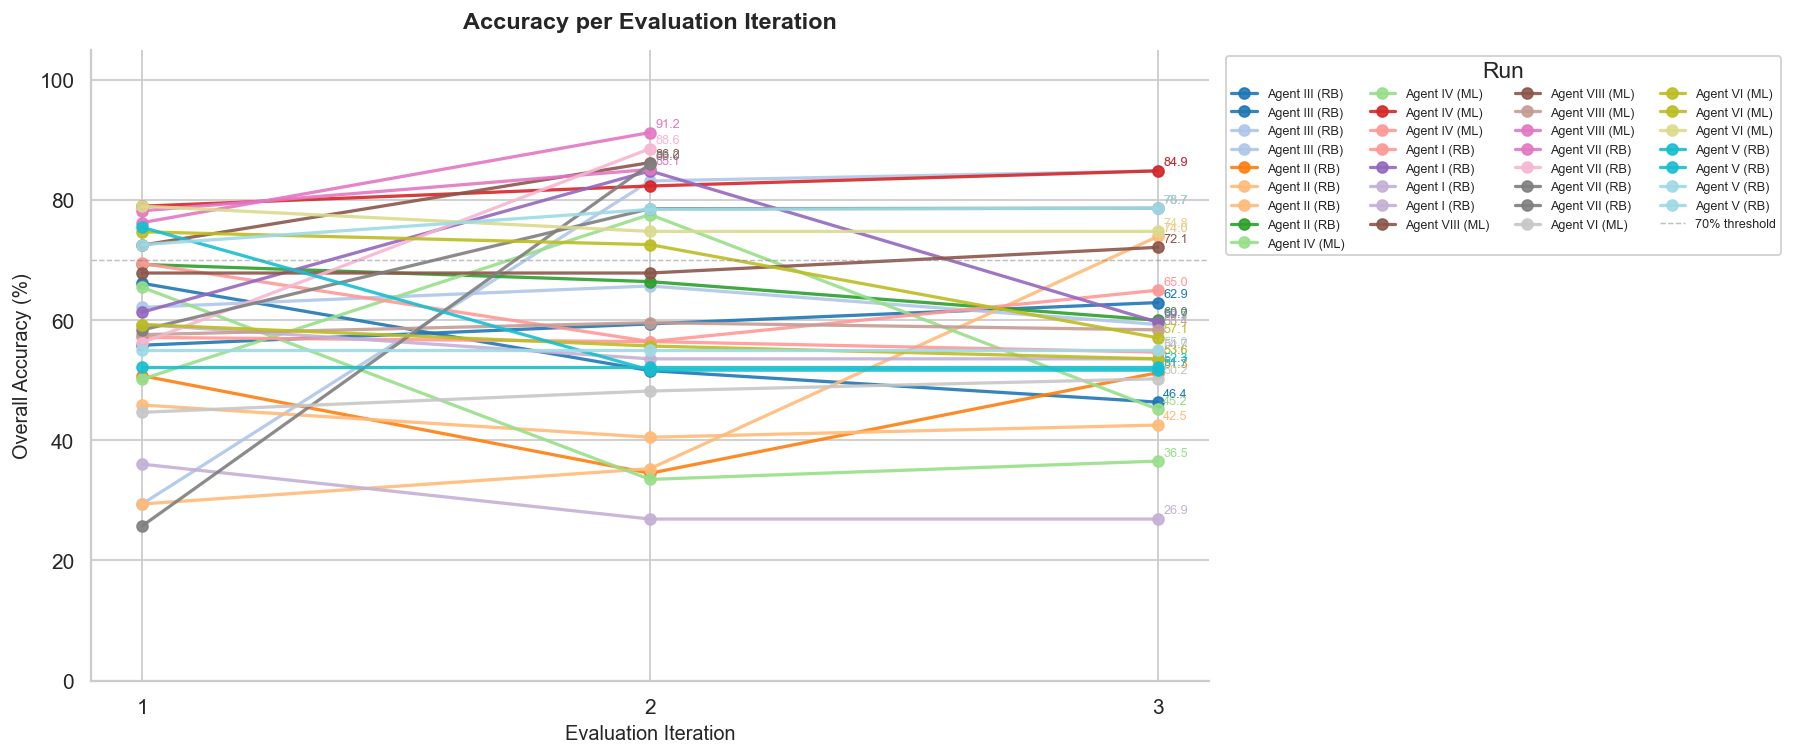

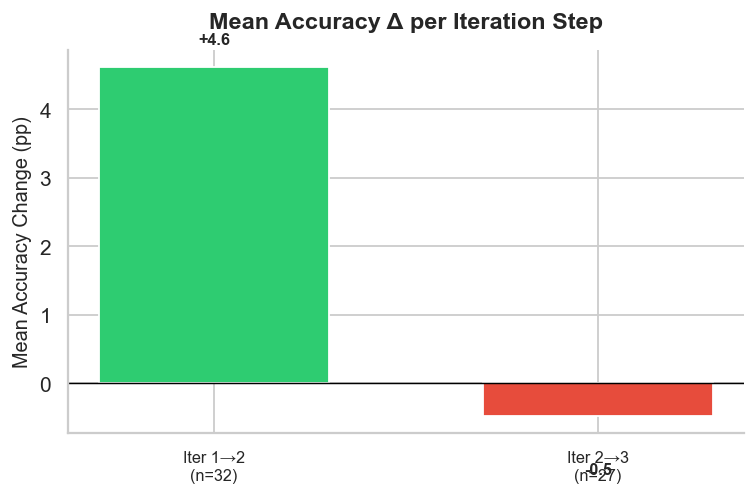

In [15]:
if all_eval.empty or all_eval["accuracy_pct"].isna().all():
    print("No accuracy data available.")
else:
    n_runs   = all_eval["run_id"].nunique()
    leg_ncol = max(1, n_runs // 10 + 1)

    # ── Plot 1: Accuracy per evaluation iteration (one line per run) ──────────
    fig, ax = plt.subplots(figsize=(14, 6))
    for run_id, grp in all_eval.groupby("run_id"):
        grp_s = grp.sort_values("eval_iteration")
        color = RUN_COLOR[run_id]
        ax.plot(grp_s["eval_iteration"], grp_s["accuracy_pct"],
                marker="o", linewidth=1.8, color=color,
                label=RUN_LABEL[run_id], alpha=0.9)
        last = grp_s.iloc[-1]
        ax.annotate(f"{last['accuracy_pct']:.1f}",
                    xy=(last["eval_iteration"], last["accuracy_pct"]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=7, color=color)
    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8, alpha=0.5,
               label="70% threshold")
    ax.set_title("Accuracy per Evaluation Iteration", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Evaluation Iteration")
    ax.set_ylabel("Overall Accuracy (%)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_ylim(0, 105)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Run", fontsize=7, ncol=leg_ncol,
              bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Mean accuracy delta per iteration step ────────────────────────
    delta_rows = []
    for run_id, grp in all_eval.groupby("run_id"):
        grp_s = grp.sort_values("eval_iteration").reset_index(drop=True)
        for j in range(1, len(grp_s)):
            p, c = grp_s.loc[j-1, "accuracy_pct"], grp_s.loc[j, "accuracy_pct"]
            if p is not None and c is not None:
                delta_rows.append({"step": f"Iter {j}\u2192{j+1}", "delta": c - p})

    if delta_rows:
        mean_delta = (pd.DataFrame(delta_rows)
                        .groupby("step", sort=False)["delta"]
                        .agg(mean_delta="mean", n="count")
                        .reset_index()
                        .sort_values("step"))

        fig, ax2 = plt.subplots(figsize=(max(6, len(mean_delta) * 1.4), 4))
        colors = ["#2ecc71" if d >= 0 else "#e74c3c" for d in mean_delta["mean_delta"]]
        bars   = ax2.bar(range(len(mean_delta)), mean_delta["mean_delta"],
                         color=colors, edgecolor="white", width=0.6)
        ax2.set_xticks(range(len(mean_delta)))
        ax2.set_xticklabels(
            [f"{r['step']}\n(n={r['n']})" for _, r in mean_delta.iterrows()],
            fontsize=9)
        ax2.axhline(0, color="black", linewidth=0.8)
        ax2.set_title("Mean Accuracy \u0394 per Iteration Step",
                      fontsize=13, fontweight="bold", pad=12)
        ax2.set_ylabel("Mean Accuracy Change (pp)")
        ax2.spines[["top", "right"]].set_visible(False)
        for bar, val in zip(bars, mean_delta["mean_delta"]):
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     val + (0.3 if val >= 0 else -0.9),
                     f"{val:+.1f}", ha="center", va="bottom", fontsize=9,
                     fontweight="bold")
        plt.tight_layout()
        plt.show()


In [ ]:
# ── 3b: Mean accuracy delta per iteration step for each pipeline ────────────
if all_eval.empty or all_eval['accuracy_pct'].isna().all() or not pipeline_types:
    print('No pipeline-type accuracy data available.')
else:
    delta_rows = []
    for run_id, grp in all_eval.groupby('run_id'):
        pt = grp['pipeline_type'].iloc[0]
        grp_s = grp.sort_values('eval_iteration').reset_index(drop=True)
        for j in range(1, len(grp_s)):
            prev_acc = grp_s.loc[j - 1, 'accuracy_pct']
            curr_acc = grp_s.loc[j, 'accuracy_pct']
            if prev_acc is not None and curr_acc is not None:
                step = f'Iter {j}→{j+1}'
                if step in {'Iter 1→2', 'Iter 2→3'}:
                    delta_rows.append({
                        'pipeline_type': pt,
                        'step': step,
                        'delta': curr_acc - prev_acc,
                    })

    if not delta_rows:
        print('Not enough eval iterations to compute deltas for Iter 1→2 and Iter 2→3.')
    else:
        df_delta = pd.DataFrame(delta_rows)
        step_order = ['Iter 1→2', 'Iter 2→3']
        pt_list = [pt for pt in pipeline_types if pt in df_delta['pipeline_type'].unique()]

        if not pt_list:
            print('No pipeline deltas found for plotting.')
        else:
            n_pt = len(pt_list)
            n_cols = 2
            n_rows = (n_pt + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(12.5, max(7.5, 3.9 * n_rows)), squeeze=False)
            axes_flat = axes.flatten()

            for i, pt in enumerate(pt_list):
                ax = axes_flat[i]
                sub = df_delta[df_delta['pipeline_type'] == pt]

                means = (sub.groupby('step')['delta']
                           .mean()
                           .reindex(step_order))
                counts = (sub.groupby('step')['delta']
                            .count()
                            .reindex(step_order)
                            .fillna(0)
                            .astype(int))

                y_vals = [0.0 if pd.isna(v) else float(v) for v in means.values]
                x = np.arange(len(step_order))
                colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in y_vals]
                bars = ax.bar(x, y_vals, width=0.62, color=colors, edgecolor='white')

                max_abs = max([abs(v) for v in y_vals] + [1.0])
                y_lim = max(4.0, max_abs * 1.55)
                ax.set_ylim(-y_lim, y_lim)
                ann_off = max(0.25, y_lim * 0.06)

                for bar, val, cnt in zip(bars, y_vals, counts.values):
                    if cnt == 0:
                        ax.text(bar.get_x() + bar.get_width() / 2, ann_off, 'n/a',
                                ha='center', va='bottom', fontsize=8, color='gray')
                        continue

                    if val >= 0:
                        txt_y = max(val + ann_off, ann_off * 1.2)
                        txt_va = 'bottom'
                    else:
                        txt_y = min(val - ann_off, -ann_off * 1.2)
                        txt_va = 'top'

                    ax.text(bar.get_x() + bar.get_width() / 2, txt_y, f'{val:+.1f}',
                            ha='center', va=txt_va, fontsize=9, fontweight='bold',
                            color=('#2ecc71' if val >= 0 else '#e74c3c'))

                ax.set_xticks(x)
                ax.set_xticklabels([f'{s}\n(n={counts[s]})' for s in step_order], fontsize=9)
                ax.axhline(0, color='black', linewidth=0.85)
                ax.set_title(clean_pipeline_label(pt), fontsize=10.5, fontweight='bold', pad=8)
                ax.set_ylabel('Mean Accuracy Change (pp)')
                ax.spines[['top', 'right']].set_visible(False)

            for j in range(n_pt, len(axes_flat)):
                axes_flat[j].set_visible(False)

            fig.suptitle('Mean Accuracy Delta per Iteration Step for Each Pipeline',
                         fontsize=13, fontweight='bold', y=1.01)
            plt.tight_layout()
            plt.show()


---
## 4 · Node Activity Analysis

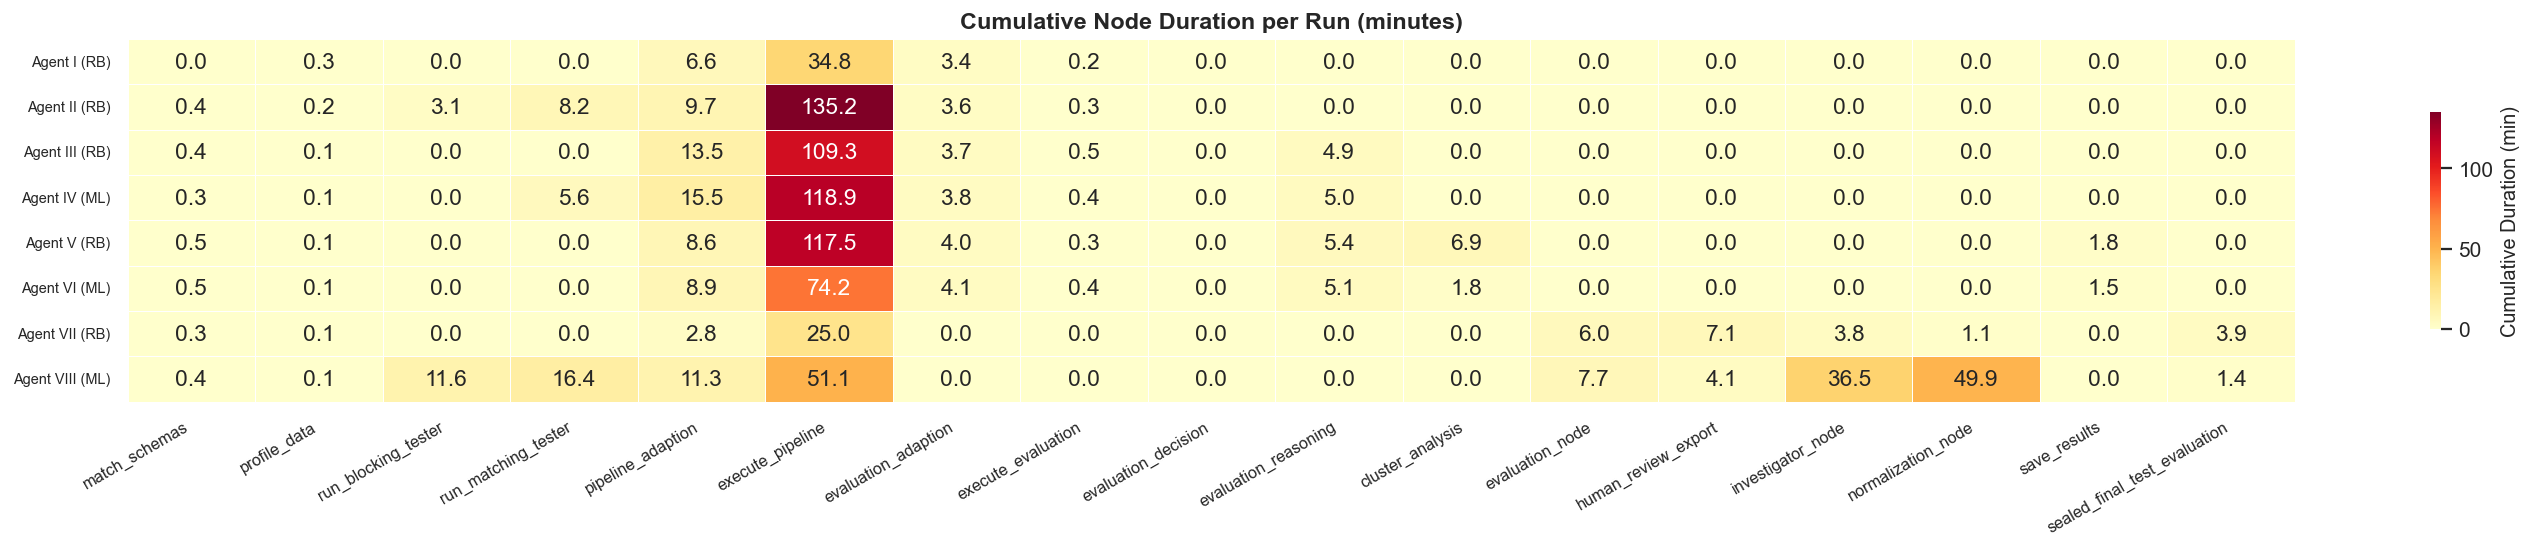

In [16]:
# ── 4a: Cumulative node duration heatmap (run x node) ─────────────────────────
tc_rows = []
for run_id, r in runs.items():
    per_node = r["time_summary"]["per_node_cumulative"]
    if not per_node:
        # Fallback: sum duration_seconds from raw node records
        per_node = (
            r["nodes"]
            .groupby("current_node")["duration_seconds"]
            .sum()
            .to_dict()
        )
    for node, dur in per_node.items():
        tc_rows.append({"label": r["label"], "node": node, "dur_s": dur})

tc_df = pd.DataFrame(tc_rows)

if not tc_df.empty:
    pivot = (tc_df.pivot_table(index="label", columns="node",
                               values="dur_s", aggfunc="sum")
                  .fillna(0))
    cols  = ([c for c in NODE_ORDER if c in pivot.columns] +
             [c for c in pivot.columns if c not in NODE_ORDER])
    pivot = pivot[cols]

    fig, ax = plt.subplots(figsize=(max(10, len(cols)*1.3),
                                    max(3, len(pivot)*0.55)))
    sns.heatmap(pivot / 60, annot=True, fmt=".1f", cmap="YlOrRd",
                linewidths=0.4, linecolor="white", ax=ax,
                cbar_kws={"label": "Cumulative Duration (min)", "shrink": 0.6})
    ax.set_title("Cumulative Node Duration per Run (minutes)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No time complexity data.")

/var/folders/99/1mpdqqd52gx9ngr3lnl8wkzh0000gn/T/ipykernel_60787/440459147.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


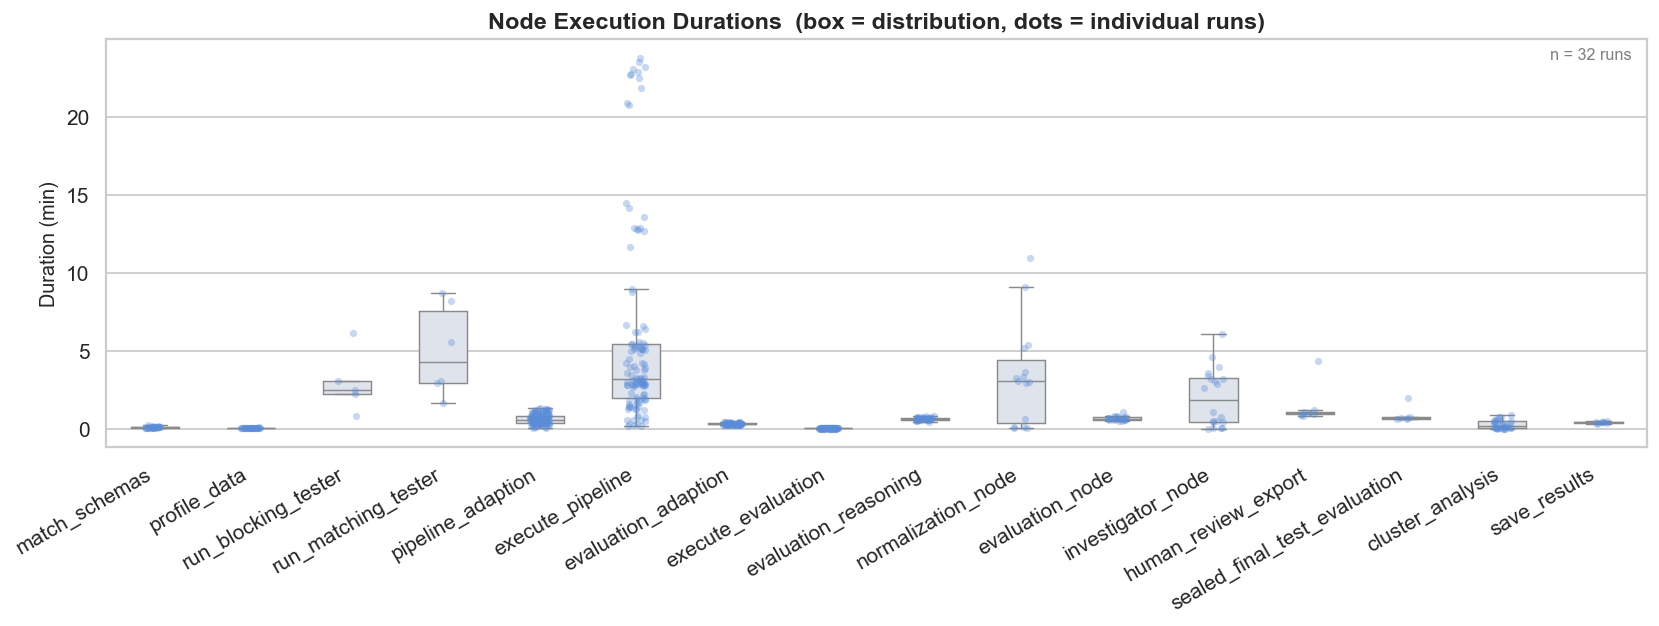

In [17]:
# ── 4b: Node duration distribution ────────────────────────────────────────────
# Box-plot always shown (summarises distribution across all runs).
# Strip overlay with per-run colours only when <= 8 runs (stays readable).
visible = all_nodes[all_nodes["duration_seconds"] > 0.1].copy()
visible["duration_min"] = visible["duration_seconds"] / 60
order   = ([n for n in NODE_ORDER if n in visible["current_node"].unique()] +
           [n for n in visible["current_node"].unique() if n not in NODE_ORDER])
n_runs  = all_nodes["run_id"].nunique()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=visible, x="current_node", y="duration_min",
            order=order, color="#dde3ee", width=0.5,
            fliersize=0, linewidth=0.8, ax=ax)

if n_runs <= 8:
    palette = {rid: RUN_COLOR[rid] for rid in all_nodes["run_id"].unique()}
    sns.stripplot(data=visible, x="current_node", y="duration_min",
                  hue="run_id", palette=palette,
                  order=order, jitter=True, size=5, alpha=0.8, ax=ax)
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, [RUN_LABEL[r] for r in all_nodes["run_id"].unique()],
              title="Run", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
else:
    # Many runs: neutral strip, count annotation
    sns.stripplot(data=visible, x="current_node", y="duration_min",
                  order=order, jitter=True, size=4, alpha=0.35,
                  color="#5b8dd9", ax=ax)
    ax.text(0.99, 0.98, f"n = {n_runs} runs",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color="gray")

ax.set_title("Node Execution Durations  (box = distribution, dots = individual runs)",
             fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Duration (min)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

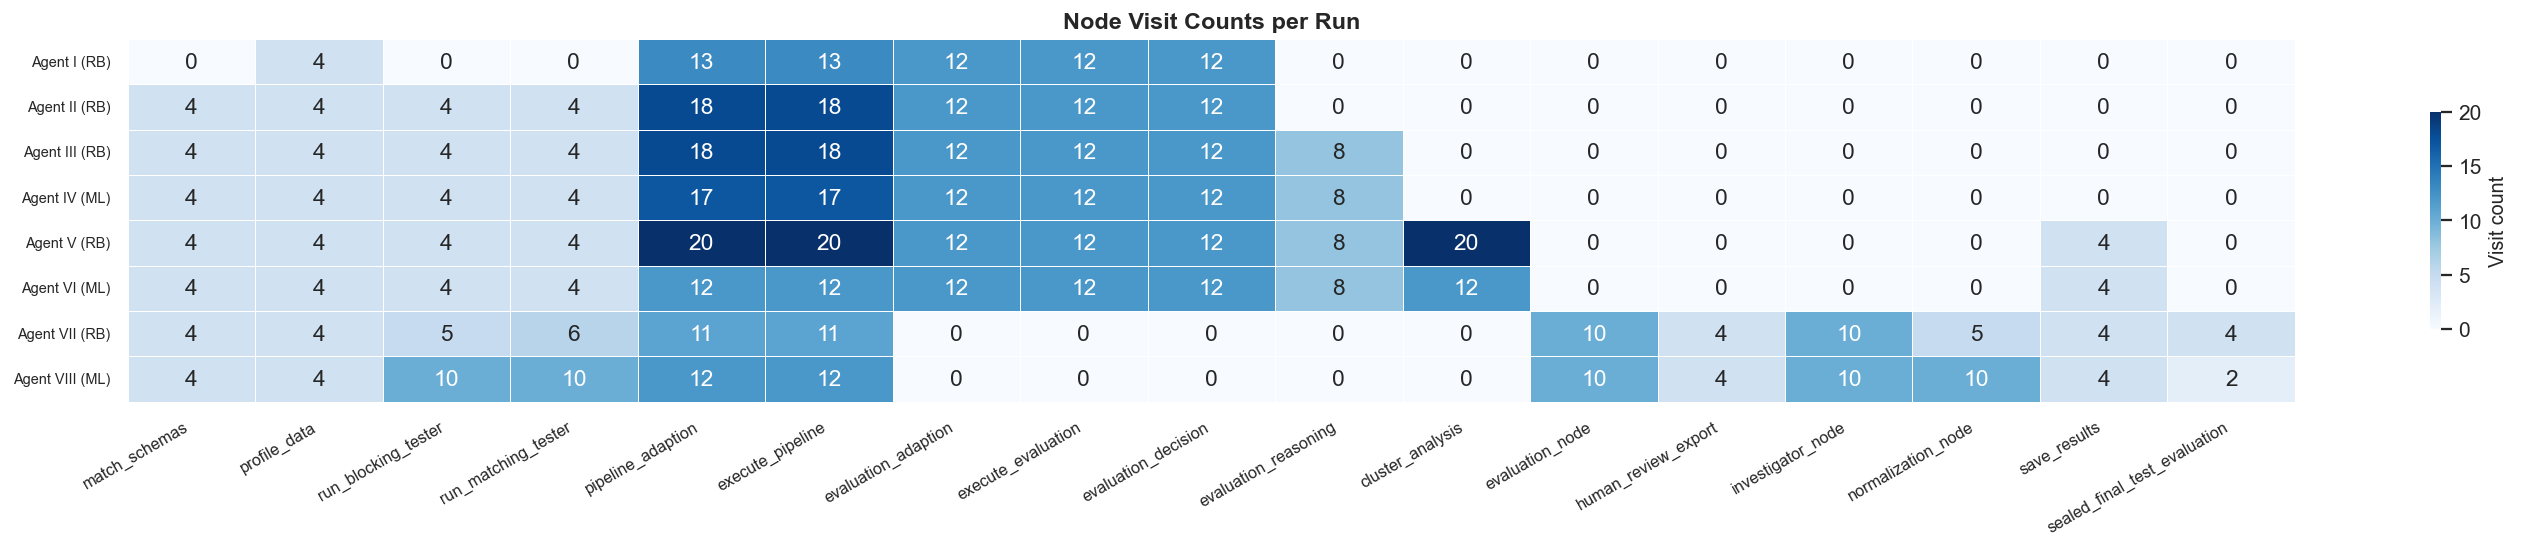

In [18]:
# ── 4c: Node visit counts heatmap (scales to any number of runs) ──────────────
pivot_v = (all_nodes.groupby(["label", "current_node"])
                    .size().reset_index(name="visits")
                    .pivot_table(index="label", columns="current_node",
                                 values="visits", aggfunc="sum")
                    .fillna(0))
cols_v  = ([c for c in NODE_ORDER if c in pivot_v.columns] +
           [c for c in pivot_v.columns if c not in NODE_ORDER])
pivot_v = pivot_v[cols_v]

fig, ax = plt.subplots(figsize=(max(10, len(cols_v)*1.3),
                                max(3, len(pivot_v)*0.55)))
sns.heatmap(pivot_v, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.4, linecolor="white", ax=ax,
            cbar_kws={"label": "Visit count", "shrink": 0.6})
ax.set_title("Node Visit Counts per Run", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

---
## 5 · Token & Cost Analysis

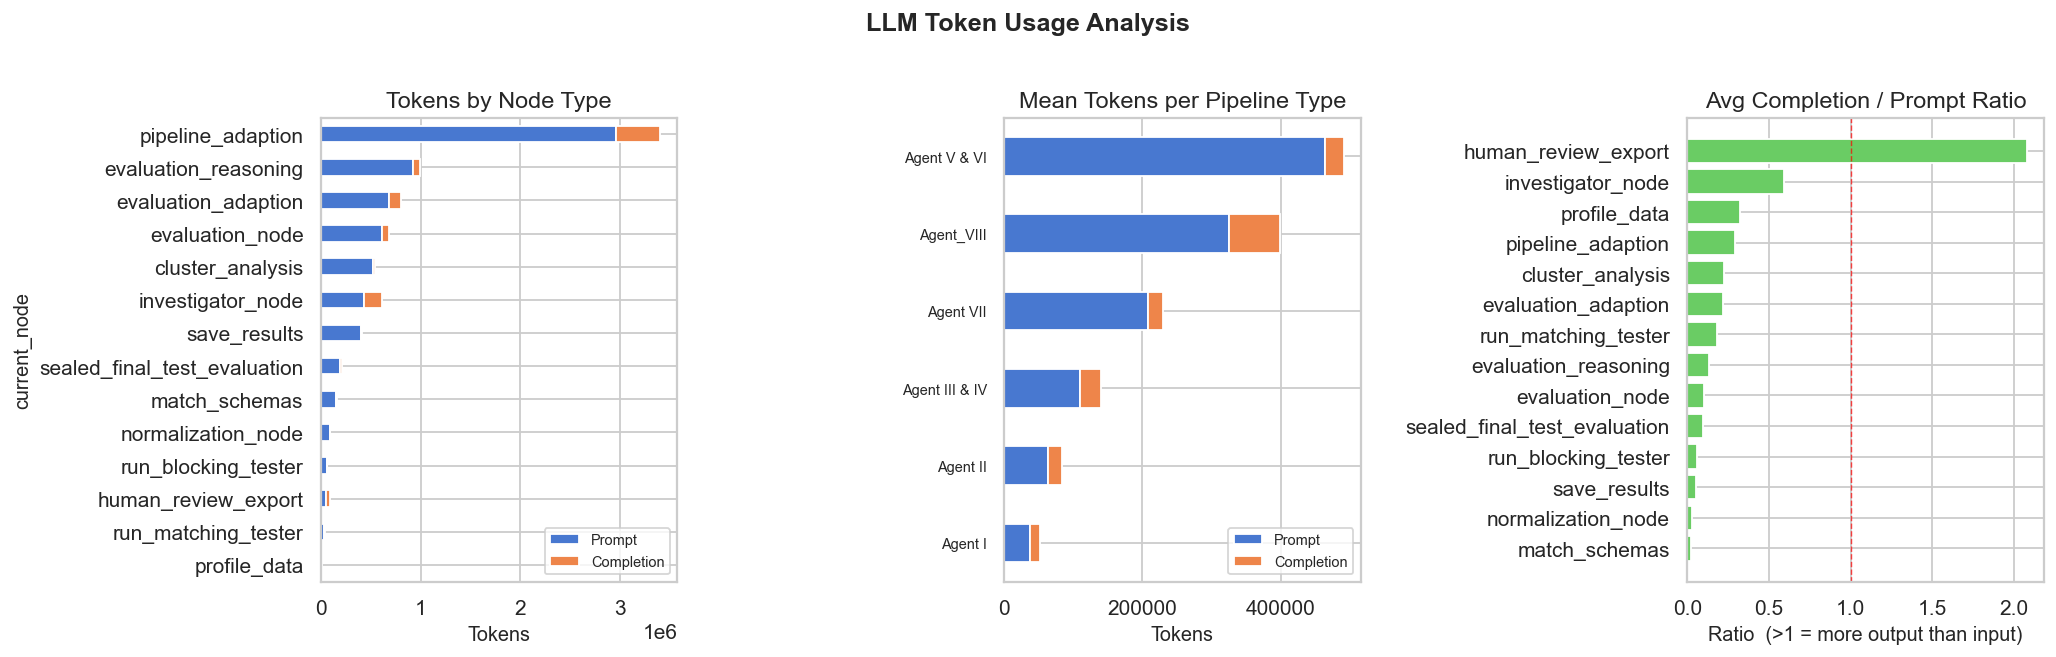

pipeline_type,method,runs,total_tokens,mean_tokens,prompt_%
Agent V & VI,rule_based,4,"3,055,756","763,939",96.4%
Agent_VIII,ml,4,"1,598,590","399,648",81.3%
Agent VII,rule_based,4,"921,162","230,290",90.4%
Agent V & VI,ml,4,"872,744","218,186",88.1%
Agent III & IV,ml,4,"598,656","149,664",78.3%
Agent III & IV,rule_based,4,"528,582","132,146",78.1%
Agent II,rule_based,4,"333,970","83,492",76.1%
Agent I,rule_based,4,"210,505","52,626",72.8%


In [19]:
token_nodes = all_nodes[all_nodes["total_tokens"] > 0].copy()
if token_nodes.empty:
    print("No token data found in logs.")
else:
    PALETTE = sns.color_palette("muted")
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 5a: Tokens per node type
    ax = axes[0]
    (token_nodes.groupby("current_node")[["prompt_tokens","completion_tokens"]]
                .sum().sort_values("prompt_tokens", ascending=True)
                .plot(kind="barh", stacked=True, ax=ax,
                      color=[PALETTE[0], PALETTE[1]], edgecolor="white"))
    ax.set_title("Tokens by Node Type")
    ax.set_xlabel("Tokens")
    ax.legend(["Prompt", "Completion"], loc="lower right", fontsize=8)

    # 5b: Total tokens per pipeline type (mean across runs of same type)
    ax2 = axes[1]
    tok_by_pt = (token_nodes.groupby(["run_id", "pipeline_type"])[["prompt_tokens","completion_tokens"]]
                             .sum().reset_index()
                             .groupby("pipeline_type")[["prompt_tokens","completion_tokens"]]
                             .mean()
                             .sort_values("prompt_tokens", ascending=True))
    tok_by_pt.plot(kind="barh", stacked=True, ax=ax2,
                   color=[PALETTE[0], PALETTE[1]], edgecolor="white")
    ax2.set_title("Mean Tokens per Pipeline Type")
    ax2.set_xlabel("Tokens")
    ax2.set_ylabel("")
    ax2.tick_params(axis="y", labelsize=8)
    ax2.legend(["Prompt", "Completion"], fontsize=8)

    # 5c: Completion/prompt ratio per node
    ax3 = axes[2]
    token_nodes["ratio"] = (token_nodes["completion_tokens"] /
                            token_nodes["prompt_tokens"].replace(0, np.nan))
    ratio_by_node = token_nodes.groupby("current_node")["ratio"].mean().sort_values()
    ax3.barh(ratio_by_node.index, ratio_by_node.values,
             color=PALETTE[2], edgecolor="white")
    ax3.axvline(1.0, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
    ax3.set_title("Avg Completion / Prompt Ratio")
    ax3.set_xlabel("Ratio  (>1 = more output than input)")

    plt.suptitle("LLM Token Usage Analysis", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    # Summary table: per pipeline type — total and mean per run
    tok_summary = (token_nodes.groupby(["run_id", "pipeline_type", "method"])
                              [["prompt_tokens","completion_tokens","total_tokens"]]
                              .sum().reset_index())
    tok_summary_pt = (tok_summary.groupby(["pipeline_type", "method"])
                                 .agg(
                                     runs          =("run_id",          "nunique"),
                                     total_tokens  =("total_tokens",    "sum"),
                                     mean_tokens   =("total_tokens",    "mean"),
                                     prompt_tokens =("prompt_tokens",   "sum"),
                                     completion_tokens=("completion_tokens","sum"),
                                 )
                                 .reset_index())
    tok_summary_pt["prompt_%"] = (
        tok_summary_pt["prompt_tokens"] / tok_summary_pt["total_tokens"] * 100
    ).round(1)
    tok_summary_pt = tok_summary_pt.sort_values("mean_tokens", ascending=False)

    display(
        tok_summary_pt[["pipeline_type","method","runs","total_tokens",
                         "mean_tokens","prompt_%"]]
        .style
        .background_gradient(subset=["mean_tokens"], cmap="Blues")
        .background_gradient(subset=["total_tokens"], cmap="Oranges")
        .format({
            "total_tokens": "{:,.0f}",
            "mean_tokens":  "{:,.0f}",
            "prompt_%":     "{:.1f}%",
        })
        .set_caption("Token Summary by Pipeline Type")
        .hide(axis="index")
    )

---
## 6 · Pipeline Type Evaluation

Comparative analysis across pipeline types — accuracy progression, delta per iteration step, efficiency, and configuration metrics.

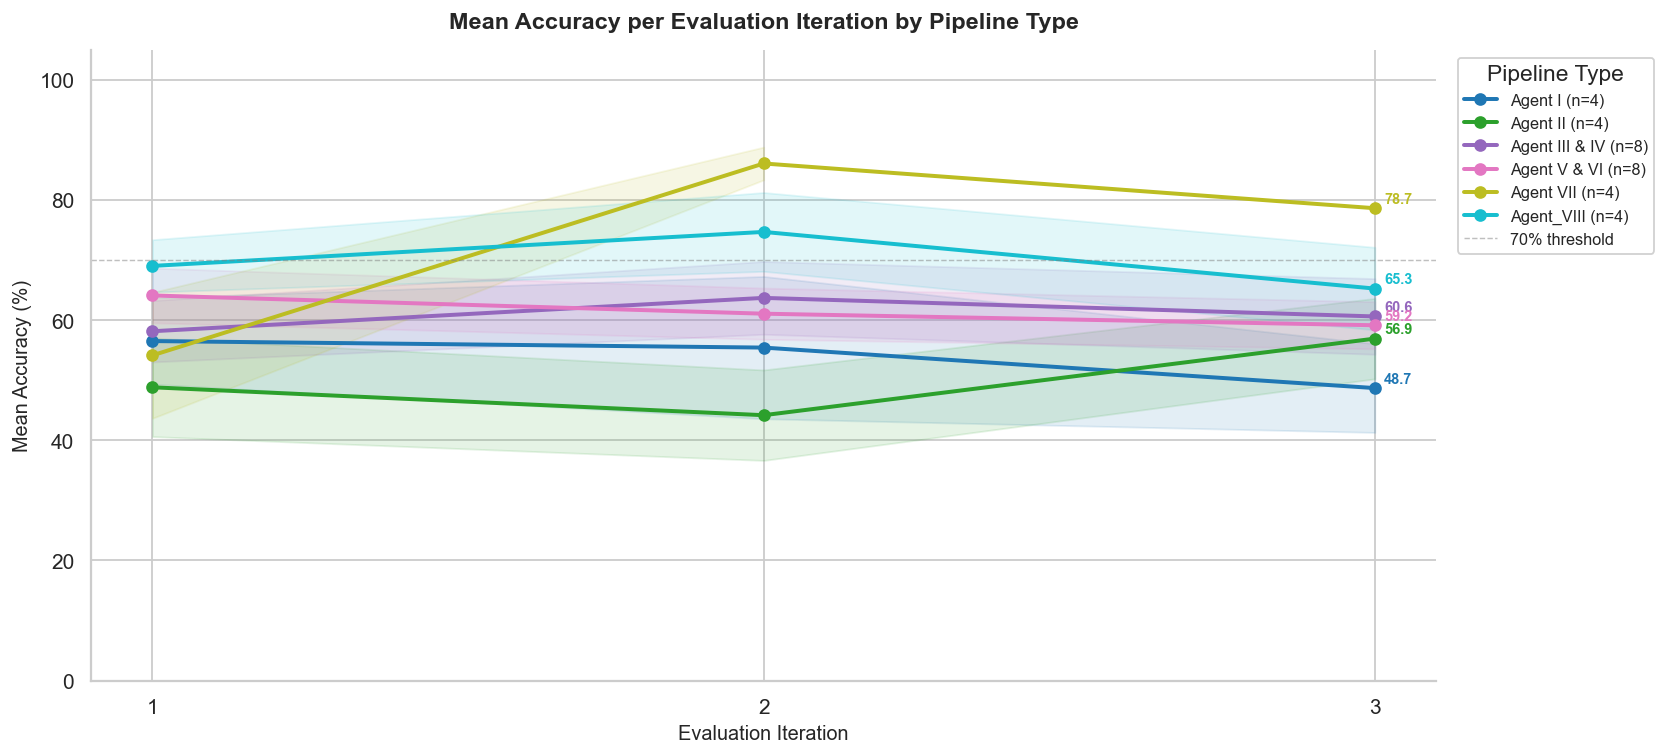

In [20]:
# ── 6a: Mean accuracy per iteration by pipeline type ─────────────────────────
if all_eval.empty or all_eval["accuracy_pct"].isna().all() or not pipeline_types:
    print("No pipeline type / accuracy data available.")
else:
    fig, ax = plt.subplots(figsize=(13, 6))

    for pt in pipeline_types:
        grp = all_eval[all_eval["pipeline_type"] == pt]
        mean_acc = (grp.groupby("eval_iteration")["accuracy_pct"]
                       .agg(mean="mean",
                            sem=lambda x: x.std() / max(len(x)**0.5, 1))
                       .reset_index())
        color    = PT_COLOR[pt]
        n_pt     = grp["run_id"].nunique()
        ax.plot(mean_acc["eval_iteration"], mean_acc["mean"],
                marker="o", linewidth=2.2, color=color,
                label=f"{pt} (n={n_pt})")
        ax.fill_between(mean_acc["eval_iteration"],
                        mean_acc["mean"] - mean_acc["sem"],
                        mean_acc["mean"] + mean_acc["sem"],
                        color=color, alpha=0.12)
        last = mean_acc.iloc[-1]
        ax.annotate(f"{last['mean']:.1f}",
                    xy=(last["eval_iteration"], last["mean"]),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=8, color=color, fontweight="bold")

    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8,
               alpha=0.5, label="70% threshold")
    ax.set_title("Mean Accuracy per Evaluation Iteration by Pipeline Type",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Evaluation Iteration")
    ax.set_ylabel("Mean Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Pipeline Type", fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    plt.show()


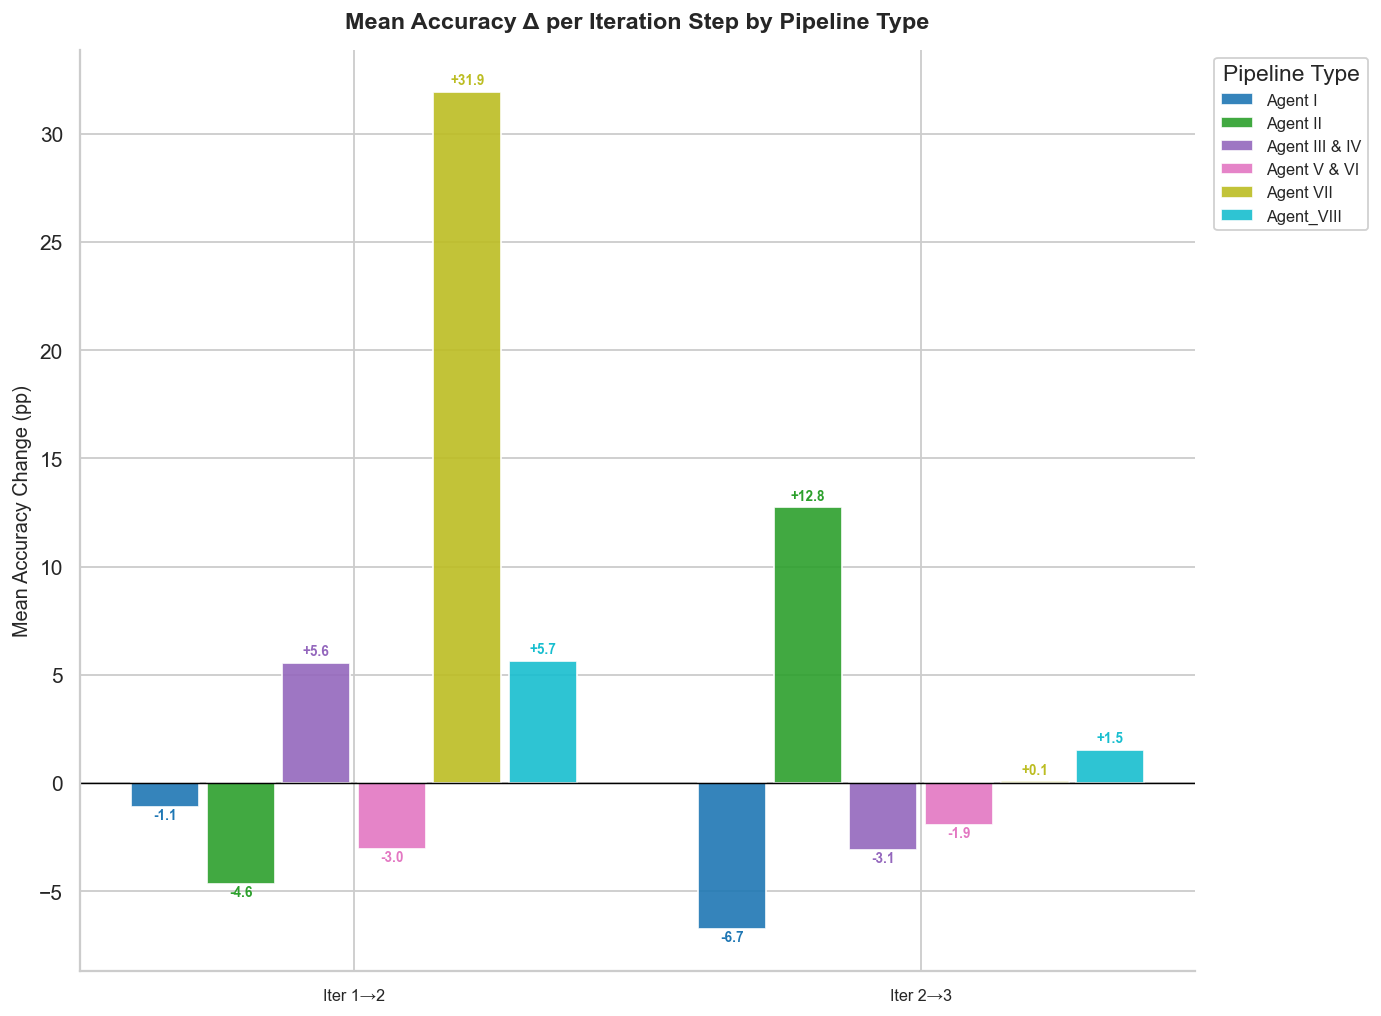

In [21]:
# ── 6b: Mean accuracy delta per step, grouped by pipeline type ───────────────
delta_rows_pt = []
for run_id, grp in all_eval.groupby("run_id"):
    pt    = grp["pipeline_type"].iloc[0]
    grp_s = grp.sort_values("eval_iteration").reset_index(drop=True)
    for j in range(1, len(grp_s)):
        p, c = grp_s.loc[j-1, "accuracy_pct"], grp_s.loc[j, "accuracy_pct"]
        if p is not None and c is not None:
            delta_rows_pt.append({
                "step":          f"Iter {j}\u2192{j+1}",
                "delta":         c - p,
                "pipeline_type": pt,
            })

if delta_rows_pt:
    df_delta_pt = pd.DataFrame(delta_rows_pt)
    steps       = sorted(df_delta_pt["step"].unique())
    n_pt        = len(pipeline_types)
    width       = 0.8 / max(n_pt, 1)
    offsets     = [i * width - (n_pt - 1) * width / 2 for i in range(n_pt)]

    fig, ax = plt.subplots(figsize=(max(8, len(steps) * n_pt * 0.9), 8))

    for i, pt in enumerate(sorted(pipeline_types)):
        grp   = df_delta_pt[df_delta_pt["pipeline_type"] == pt]
        means = grp.groupby("step")["delta"].mean().reindex(steps).fillna(0)
        cnts  = grp.groupby("step")["delta"].count().reindex(steps).fillna(0)
        x     = [j + offsets[i] for j in range(len(steps))]
        bars  = ax.bar(x, means.values, width=width * 0.9,
                       color=PT_COLOR[pt], edgecolor="white",
                       label=pt, alpha=0.9)
        for bar, val in zip(bars, means.values):
            if abs(val) > 0.05:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        val + (0.2 if val >= 0 else -0.7),
                        f"{val:+.1f}", ha="center", va="bottom",
                        fontsize=7.5, fontweight="bold", color=PT_COLOR[pt])

    ax.set_xticks(range(len(steps)))
    ax.set_xticklabels(steps, fontsize=9)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Mean Accuracy \u0394 per Iteration Step by Pipeline Type",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel("Mean Accuracy Change (pp)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Pipeline Type", fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough eval iterations to compute deltas.")


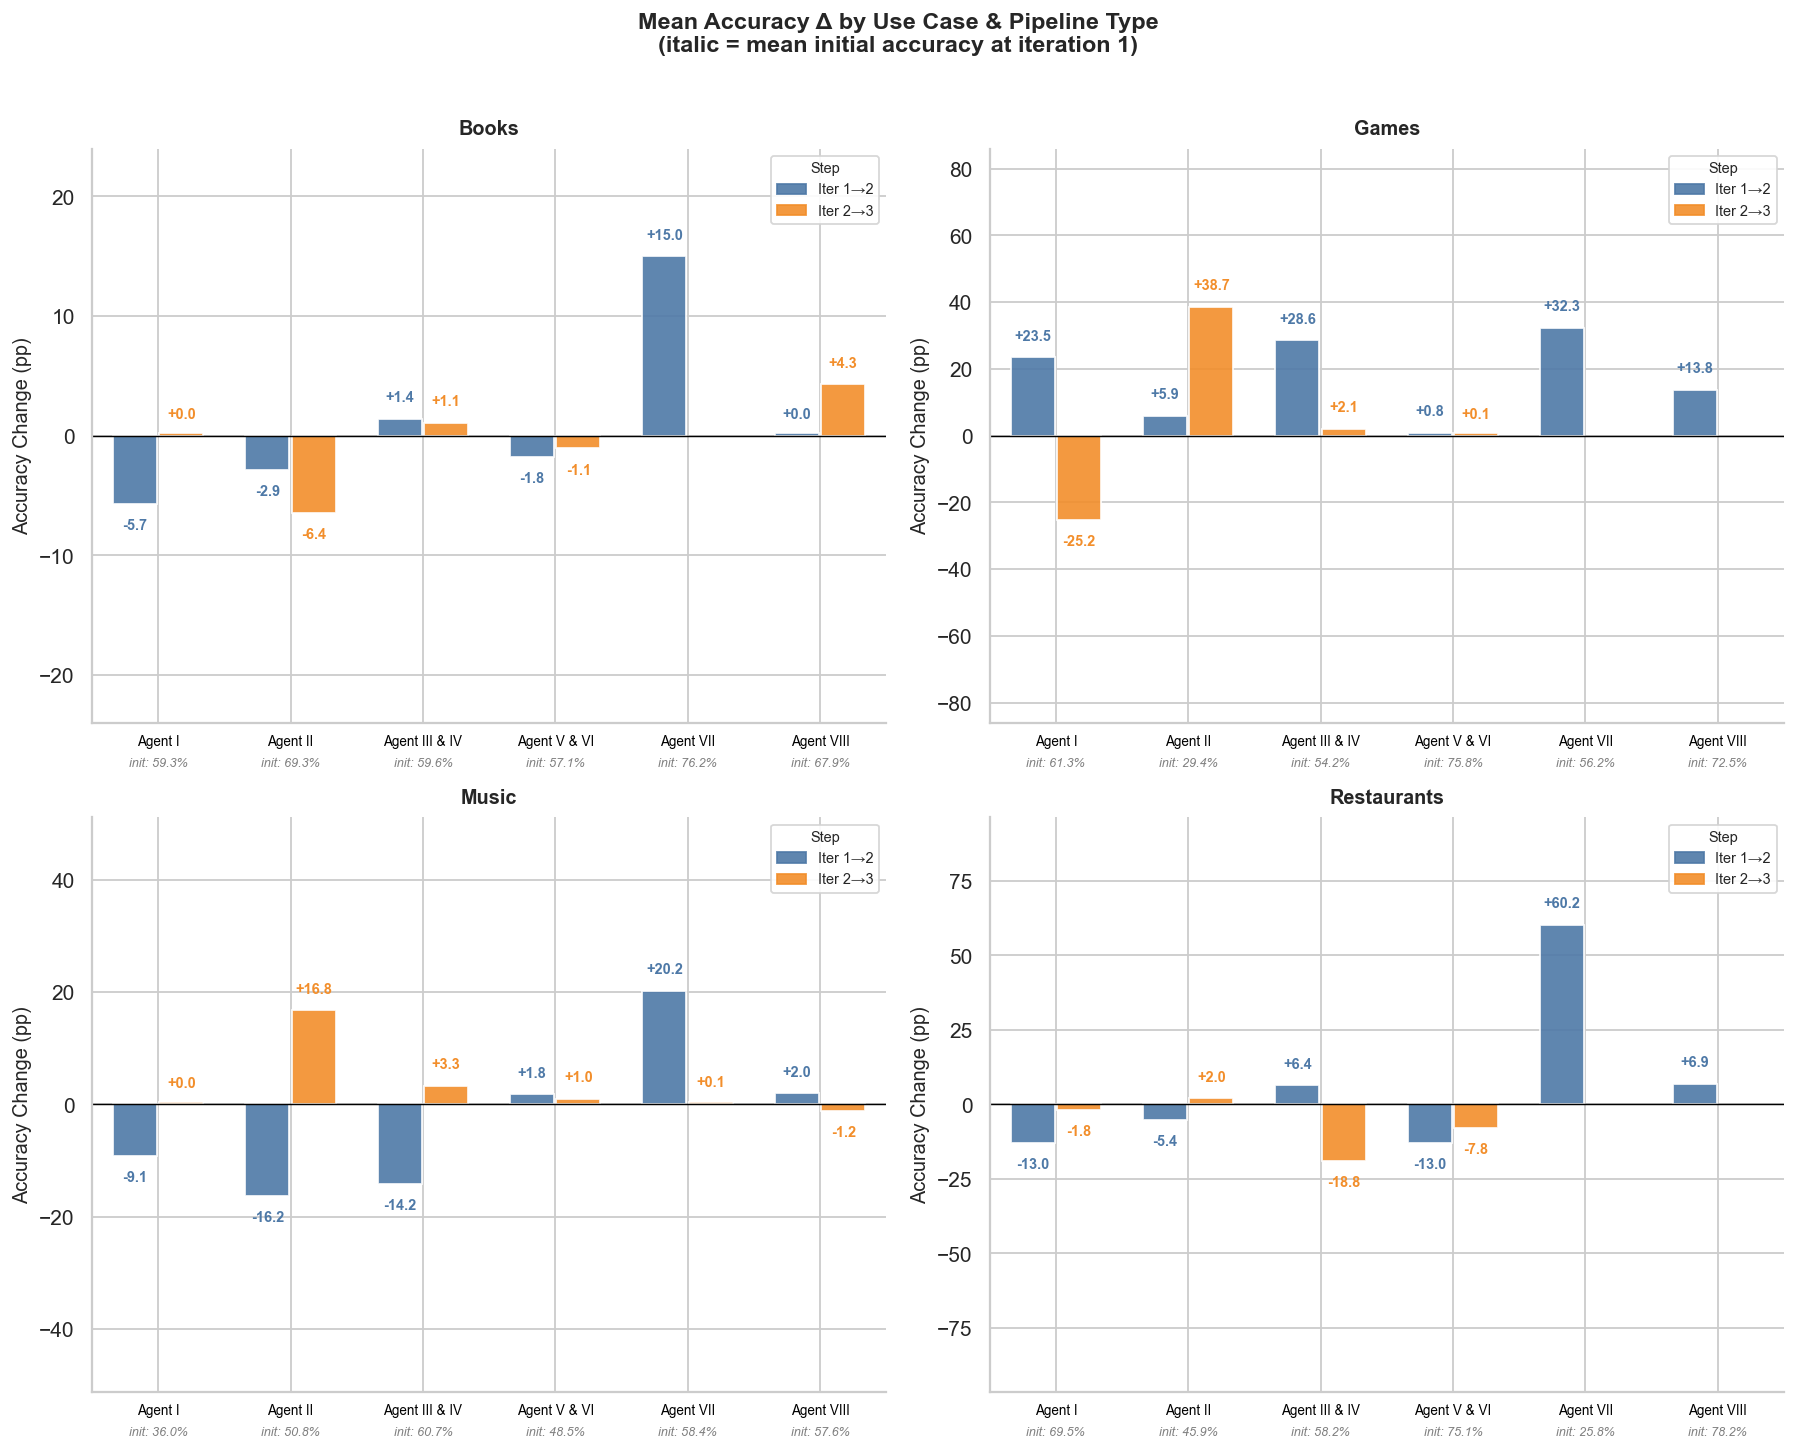

In [22]:
# ── 6b: Mean accuracy delta — one panel per use case, bars per pipeline type ──
def fmt_pt_name(pt):
    """Break long pipeline names onto two lines at natural split points."""
    return (pt.replace("AdaptationPipeline_with_new_Cluster", "AdaptationPipeline\nwith new Cluster")
              .replace("AdaptationPipeline", "Adaptation\nPipeline")
              .replace("Blocker_Matcher", "Blocker\nMatcher")
              .replace("_", " "))

delta_rows_pt = []
init_rows_pt  = []
for run_id, grp in all_eval.groupby("run_id"):
    pt    = grp["pipeline_type"].iloc[0]
    uc    = grp["use_case"].iloc[0]
    grp_s = grp.sort_values("eval_iteration").reset_index(drop=True)
    if len(grp_s) > 0 and grp_s.loc[0, "accuracy_pct"] is not None:
        init_rows_pt.append({
            "pipeline_type": pt,
            "use_case":      uc,
            "init_acc":      grp_s.loc[0, "accuracy_pct"],
        })
    for j in range(1, len(grp_s)):
        p, c = grp_s.loc[j-1, "accuracy_pct"], grp_s.loc[j, "accuracy_pct"]
        if p is not None and c is not None:
            delta_rows_pt.append({
                "step":          f"Iter {j}\u2192{j+1}",
                "delta":         c - p,
                "pipeline_type": pt,
                "use_case":      uc,
            })

if delta_rows_pt:
    df_delta_pt = pd.DataFrame(delta_rows_pt)
    df_init_pt  = pd.DataFrame(init_rows_pt)

    pt_list = sorted(df_delta_pt["pipeline_type"].unique())
    steps   = sorted(df_delta_pt["step"].unique())
    uc_list = sorted(df_delta_pt["use_case"].unique())

    n_uc    = len(uc_list)
    n_pt    = len(pt_list)
    n_steps = len(steps)

    step_colors = ["#4e79a7", "#f28e2b"][:n_steps]

    group_w = 0.7
    width   = group_w / n_steps
    offsets = [i * width - (n_steps - 1) * width / 2 for i in range(n_steps)]

    n_cols = min(n_uc, 2)
    n_rows = (n_uc + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(7 * n_cols, 5.5 * n_rows),
                             squeeze=False)
    fig.subplots_adjust(bottom=0.15)
    axes_flat = axes.flatten()

    for idx, uc in enumerate(uc_list):
        ax  = axes_flat[idx]
        sub = df_delta_pt[df_delta_pt["use_case"] == uc]

        uc_abs_max   = sub["delta"].abs().max()
        uc_y_lim     = max(uc_abs_max * 1.6, 5)
        label_offset = uc_y_lim * 0.05

        # ── bars ──────────────────────────────────────────────────────────────
        for s_idx, step in enumerate(steps):
            step_sub = sub[sub["step"] == step]
            means    = (step_sub.groupby("pipeline_type")["delta"]
                                .mean()
                                .reindex(pt_list)
                                .fillna(float("nan")))
            x = [j + offsets[s_idx] for j in range(n_pt)]

            for xi, (pt, val) in enumerate(zip(pt_list, means.values)):
                if pd.isna(val):
                    continue
                bar_val = val if abs(val) > uc_y_lim * 0.01 else (
                    uc_y_lim * 0.01 * (1 if val >= 0 else -1))
                ax.bar(x[xi], bar_val, width=width * 0.95,
                       color=step_colors[s_idx], edgecolor="white",
                       alpha=0.9)
                ax.text(x[xi],
                        val + (label_offset if val >= 0 else -label_offset),
                        f"{val:+.1f}", ha="center",
                        va="bottom" if val >= 0 else "top",
                        fontsize=8, fontweight="bold",
                        color=step_colors[s_idx])

        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(uc, fontsize=11, fontweight="bold", pad=8)
        ax.set_xlim(-0.5, n_pt - 0.5)
        ax.set_ylim(-uc_y_lim, uc_y_lim)
        ax.set_ylabel("Accuracy Change (pp)")
        ax.spines[["top", "right"]].set_visible(False)

        # ── x-axis: pipeline name + init accuracy, tightly stacked ───────────
        init_sub   = df_init_pt[df_init_pt["use_case"] == uc]
        init_means = (init_sub.groupby("pipeline_type")["init_acc"]
                               .mean()
                               .reindex(pt_list))

        ax.set_xticks(range(n_pt))
        ax.set_xticklabels([""] * n_pt)
        ax.tick_params(axis="x", length=0)

        for xi, pt in enumerate(pt_list):
            init_val = init_means.get(pt, float("nan"))
            name     = fmt_pt_name(pt)

            # pipeline name — black, normal weight
            ax.text(xi, -0.02,
                    name,
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="top",
                    fontsize=7.5, color="black",
                    multialignment="center",
                    linespacing=1.3)

            # init accuracy — gray italic, directly below name
            if not pd.isna(init_val):
                # count lines in name to know how far to offset
                n_name_lines = name.count("\n") + 1
                y_offset     = -0.06
                ax.text(xi, y_offset,
                        f"init: {init_val:.1f}%",
                        transform=ax.get_xaxis_transform(),
                        ha="center", va="top",
                        fontsize=7, color="gray", style="italic",
                        multialignment="center")

        # ── legend ────────────────────────────────────────────────────────────
        handles = [mpatches.Patch(color=step_colors[s_idx], label=step, alpha=0.9)
                   for s_idx, step in enumerate(steps)]
        ax.legend(handles=handles, title="Step", fontsize=8, title_fontsize=8,
                  loc="upper right", framealpha=0.9, edgecolor="lightgray")

    for ax in axes_flat[n_uc:]:
        ax.set_visible(False)

    fig.suptitle("Mean Accuracy \u0394 by Use Case & Pipeline Type\n"
                 "(italic = mean initial accuracy at iteration 1)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

else:
    print("Not enough eval iterations to compute deltas.")

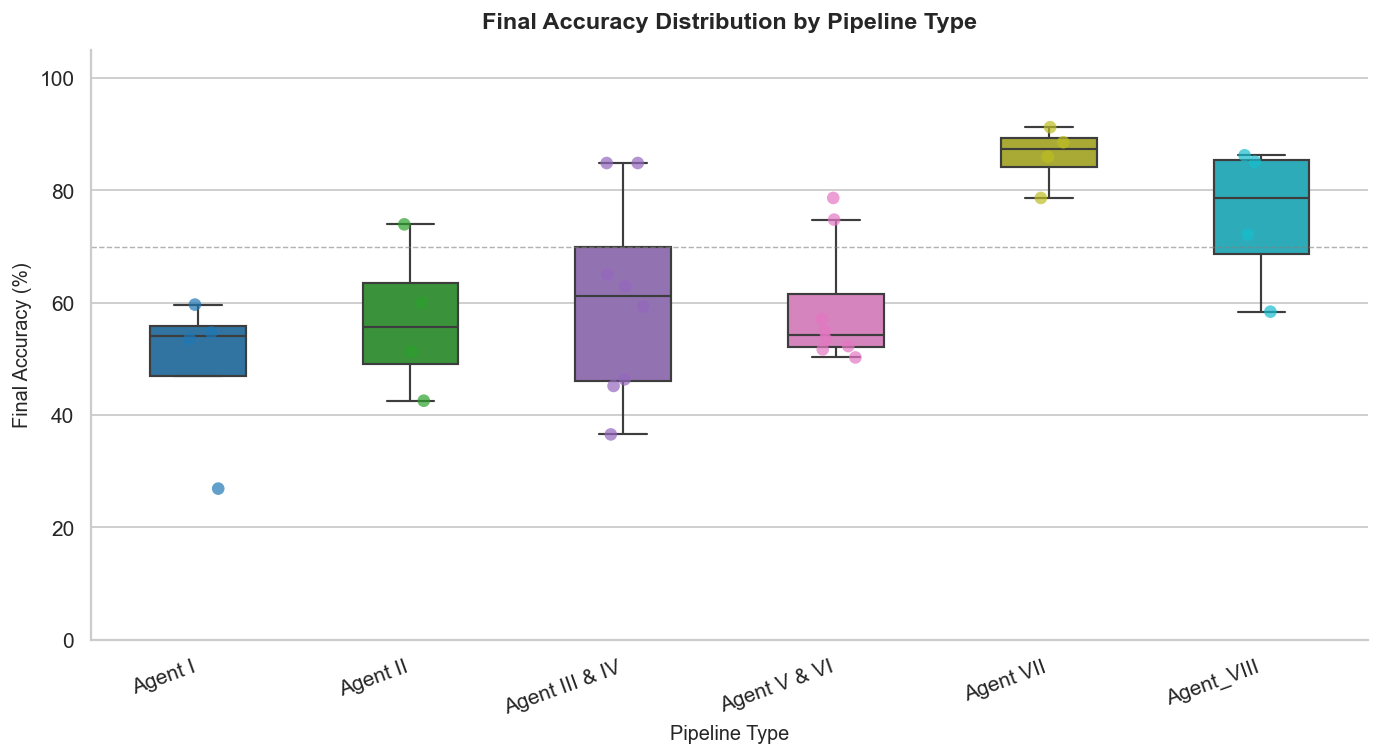


Pairwise t-tests (final accuracy):
  Pair                                            t-stat     p-value    sig
  ------------------------------------------------------------------------
  Agent I vs Agent II                             -0.826      0.4406   n.s.
  Agent I vs Agent III & IV                       -1.228      0.2575   n.s.
  Agent I vs Agent V & VI                         -1.251      0.2690   n.s.
  Agent I vs Agent VII                            -4.754      0.0102      *
  Agent I vs Agent_VIII                           -2.715      0.0354      *
  Agent II vs Agent III & IV                      -0.401      0.6987   n.s.
  Agent II vs Agent V & VI                        -0.286      0.7859   n.s.
  Agent II vs Agent VII                           -4.039      0.0160      *
  Agent II vs Agent_VIII                          -1.982      0.0948   n.s.
  Agent III & IV vs Agent V & VI                   0.198      0.8464   n.s.
  Agent III & IV vs Agent VII                     -3.

In [23]:
# ── 6c: Final accuracy distribution per pipeline type (box + strip) ──────────
if not all_eval.empty and pipeline_types:
    # Get final accuracy per run
    final_acc = (all_eval.sort_values("eval_iteration")
                         .groupby("run_id")
                         .last()
                         .reset_index()[["run_id","pipeline_type","accuracy_pct"]]
                         .dropna(subset=["accuracy_pct"]))

    # Only include pipeline types that actually appear in final_acc, preserving order
    pt_order = [pt for pt in pipeline_types if pt in final_acc["pipeline_type"].values]

    fig, ax = plt.subplots(figsize=(max(7, len(pt_order) * 1.8), 6))
    sns.boxplot(data=final_acc, x="pipeline_type", y="accuracy_pct",
                order=pt_order, palette=PT_COLOR, width=0.45, fliersize=0,
                linewidth=1.2, ax=ax)
    sns.stripplot(data=final_acc, x="pipeline_type", y="accuracy_pct",
                  order=pt_order, palette=PT_COLOR, jitter=True, size=7,
                  alpha=0.7, ax=ax)
    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8, alpha=0.6,
               label="70% threshold")
    ax.set_title("Final Accuracy Distribution by Pipeline Type",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Pipeline Type")
    ax.set_ylabel("Final Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    # Statistical significance: pairwise t-tests if >= 2 types with >= 2 runs each
    groups   = [grp["accuracy_pct"].values
                for pt in pt_order
                for _, grp in [("", final_acc[final_acc["pipeline_type"] == pt])]
                if len(grp) >= 2]
    labels_g = [pt for pt in pt_order
                if len(final_acc[final_acc["pipeline_type"] == pt]) >= 2]

    if len(groups) >= 2:
        print("\nPairwise t-tests (final accuracy):")
        print(f"  {'Pair':<45} {'t-stat':>8}  {'p-value':>10}  {'sig':>5}")
        print("  " + "-"*72)
        from itertools import combinations
        for (i, j) in combinations(range(len(groups)), 2):
            t, p = stats.ttest_ind(groups[i], groups[j], equal_var=False)
            sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
            pair = f"{labels_g[i]} vs {labels_g[j]}"
            print(f"  {pair:<45} {t:>8.3f}  {p:>10.4f}  {sig:>5}")

pipeline_type,runs,mean_final_acc,mean_gain_pp,mean_iters,mean_tokens,mean_duration_min,mean_tokens_per_pp,mean_acc_per_token_k,mean_acc_per_min
Agent I,4,48.70%,-7.83pp,3.0,"52,626",12.3 min,"5,262,625",0.950,5.15
Agent II,4,56.94%,+8.11pp,3.0,"83,492",41.3 min,"4,387,294",0.729,2.07
Agent III & IV,8,60.63%,+2.46pp,3.0,"140,905",37.0 min,"7,612,099",0.463,1.97
Agent V & VI,8,59.16%,-4.96pp,3.0,"491,062",32.1 min,"32,893,644",0.203,2.29
Agent VII,4,86.12%,+31.96pp,2.2,"230,290",12.9 min,"9,207",0.411,7.12
Agent_VIII,4,75.47%,+6.43pp,2.5,"399,648",48.9 min,"206,234",0.213,1.77


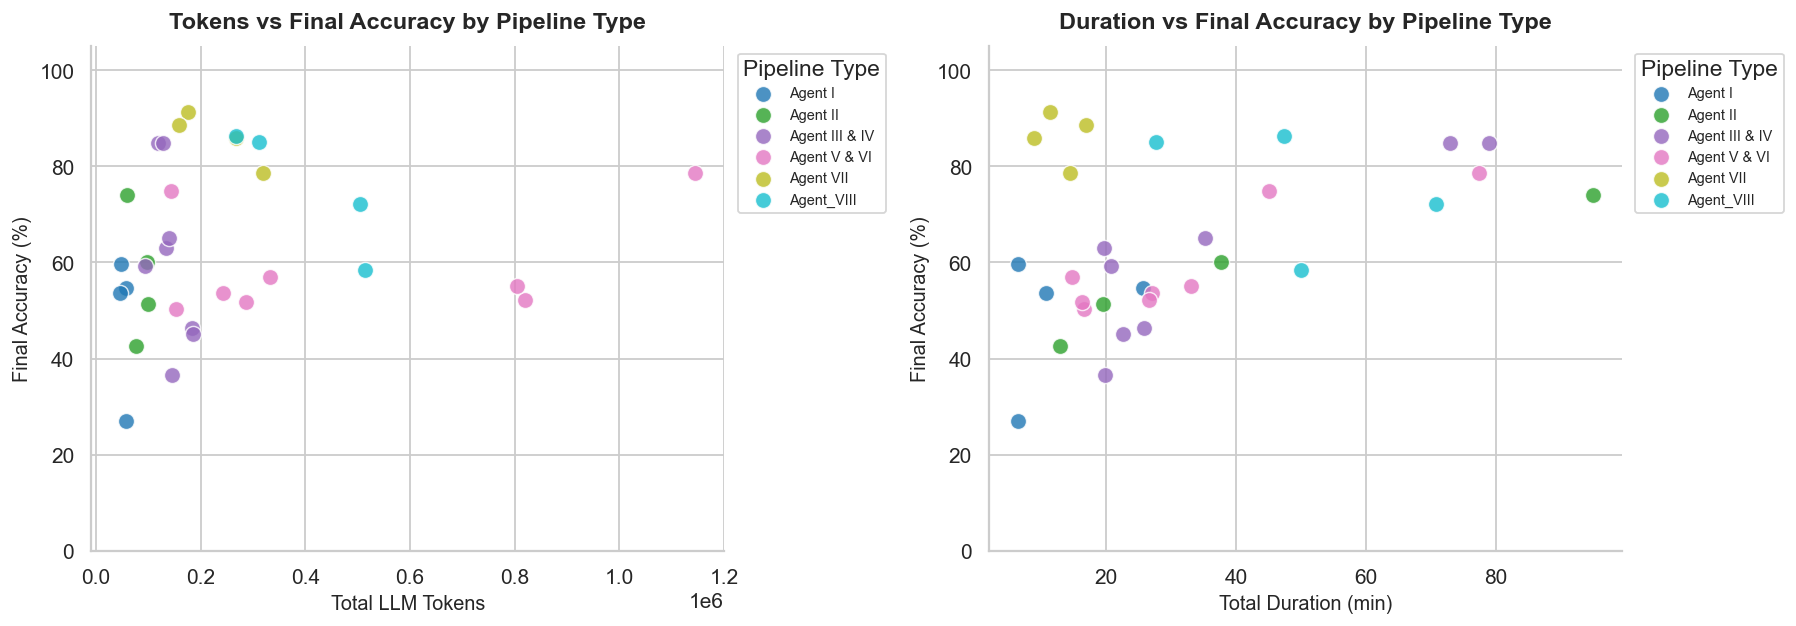

In [24]:
# ── 6d: Efficiency metrics by pipeline type ───────────────────────────────────
if not all_eval.empty and pipeline_types:
    eff_rows = []
    for run_id, r in runs.items():
        pt         = r["pipeline_type"]
        method     = r["method"]
        accuracies = [e["accuracy_pct"] for e in r["eval_runs"] if e["accuracy_pct"] is not None]
        tokens     = int(r["nodes"]["total_tokens"].sum())
        duration   = r["time_summary"]["total_duration_s"]
        n_iters    = len(r["eval_runs"])
        final_acc  = accuracies[-1] if accuracies else None
        gain       = (accuracies[-1] - accuracies[0]) if len(accuracies) > 1 else 0.0

        eff_rows.append({
            "pipeline_type":      pt,
            "method":             method,
            "run_id":             run_id,
            "final_acc":          final_acc,
            "gain_pp":            gain,
            "n_iters":            n_iters,
            "total_tokens":       tokens,
            "duration_min":       duration / 60,
            "tokens_per_pp":      tokens / max(gain, 0.01),
            "acc_per_token_k":    (final_acc or 0) / max(tokens / 1000, 0.01),
            "acc_per_min":        (final_acc or 0) / max(duration / 60, 0.01),
        })

    df_eff = pd.DataFrame(eff_rows)

    # Summary by pipeline type — preserve pipeline_types order
    eff_summary = (df_eff.groupby("pipeline_type")
                         .agg(
                             runs                =("run_id",          "count"),
                             mean_final_acc      =("final_acc",       "mean"),
                             mean_gain_pp        =("gain_pp",         "mean"),
                             mean_iters          =("n_iters",         "mean"),
                             mean_tokens         =("total_tokens",    "mean"),
                             mean_duration_min   =("duration_min",    "mean"),
                             mean_tokens_per_pp  =("tokens_per_pp",   "mean"),
                             mean_acc_per_token_k=("acc_per_token_k", "mean"),
                             mean_acc_per_min    =("acc_per_min",     "mean"),
                         )
                         .reset_index())

    # Apply the canonical pipeline_types order
    pt_order_idx = {pt: i for i, pt in enumerate(pipeline_types)}
    eff_summary["_order"] = eff_summary["pipeline_type"].map(pt_order_idx)
    eff_summary = eff_summary.sort_values("_order").drop(columns="_order").reset_index(drop=True)

    display(
        eff_summary.style
        .background_gradient(subset=["mean_final_acc"],        cmap="YlGn",   vmin=40, vmax=100)
        .background_gradient(subset=["mean_gain_pp"],          cmap="Blues")
        .background_gradient(subset=["mean_tokens"],           cmap="Oranges")
        .background_gradient(subset=["mean_acc_per_token_k"],  cmap="Greens")
        .background_gradient(subset=["mean_acc_per_min"],      cmap="Purples")
        .format({
            "mean_final_acc":        "{:.2f}%",
            "mean_gain_pp":          "{:+.2f}pp",
            "mean_iters":            "{:.1f}",
            "mean_tokens":           "{:,.0f}",
            "mean_duration_min":     "{:.1f} min",
            "mean_tokens_per_pp":    "{:,.0f}",
            "mean_acc_per_token_k":  "{:.3f}",
            "mean_acc_per_min":      "{:.2f}",
        })
        .set_caption("Efficiency Summary by Pipeline Type")
        .hide(axis="index")
    )

    # Scatter: tokens vs final accuracy coloured by pipeline type
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, xcol, xlabel in zip(axes,
            ["total_tokens", "duration_min"],
            ["Total LLM Tokens", "Total Duration (min)"]):
        for pt in pipeline_types:
            sub = df_eff[df_eff["pipeline_type"] == pt]
            ax.scatter(sub[xcol], sub["final_acc"],
                       color=PT_COLOR[pt], label=pt,
                       s=80, alpha=0.8, edgecolors="white", linewidth=0.8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Final Accuracy (%)")
        ax.set_ylim(0, 105)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(title="Pipeline Type", fontsize=8,
                  bbox_to_anchor=(1.01, 1), loc="upper left")

    axes[0].set_title("Tokens vs Final Accuracy by Pipeline Type",
                      fontweight="bold", pad=10)
    axes[1].set_title("Duration vs Final Accuracy by Pipeline Type",
                      fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()

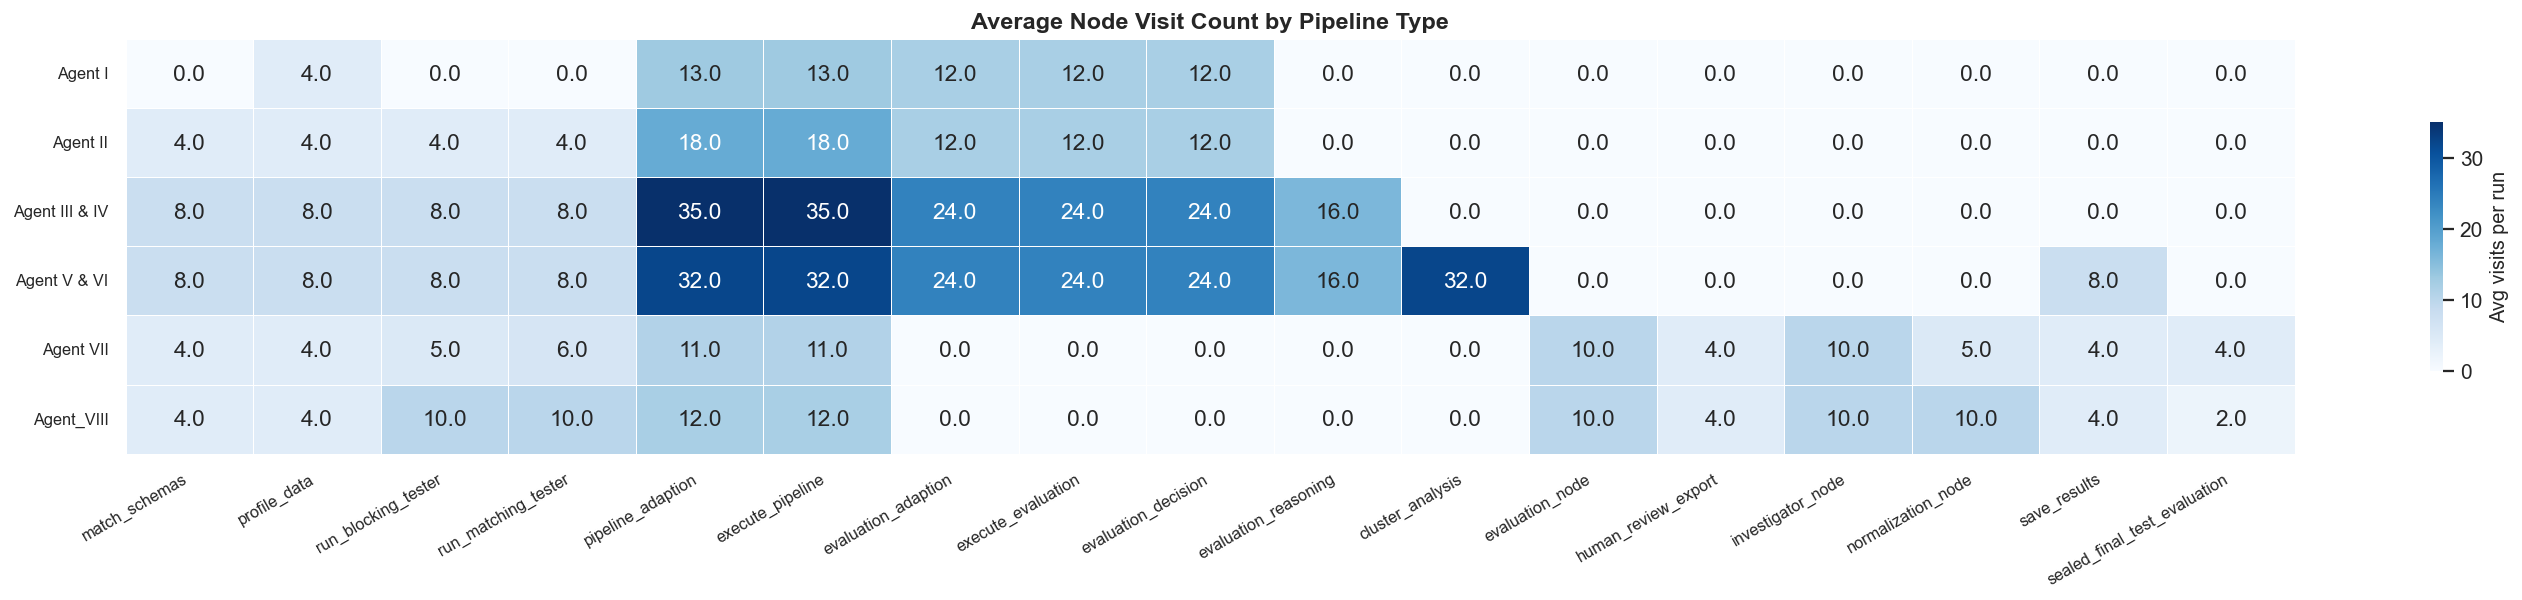

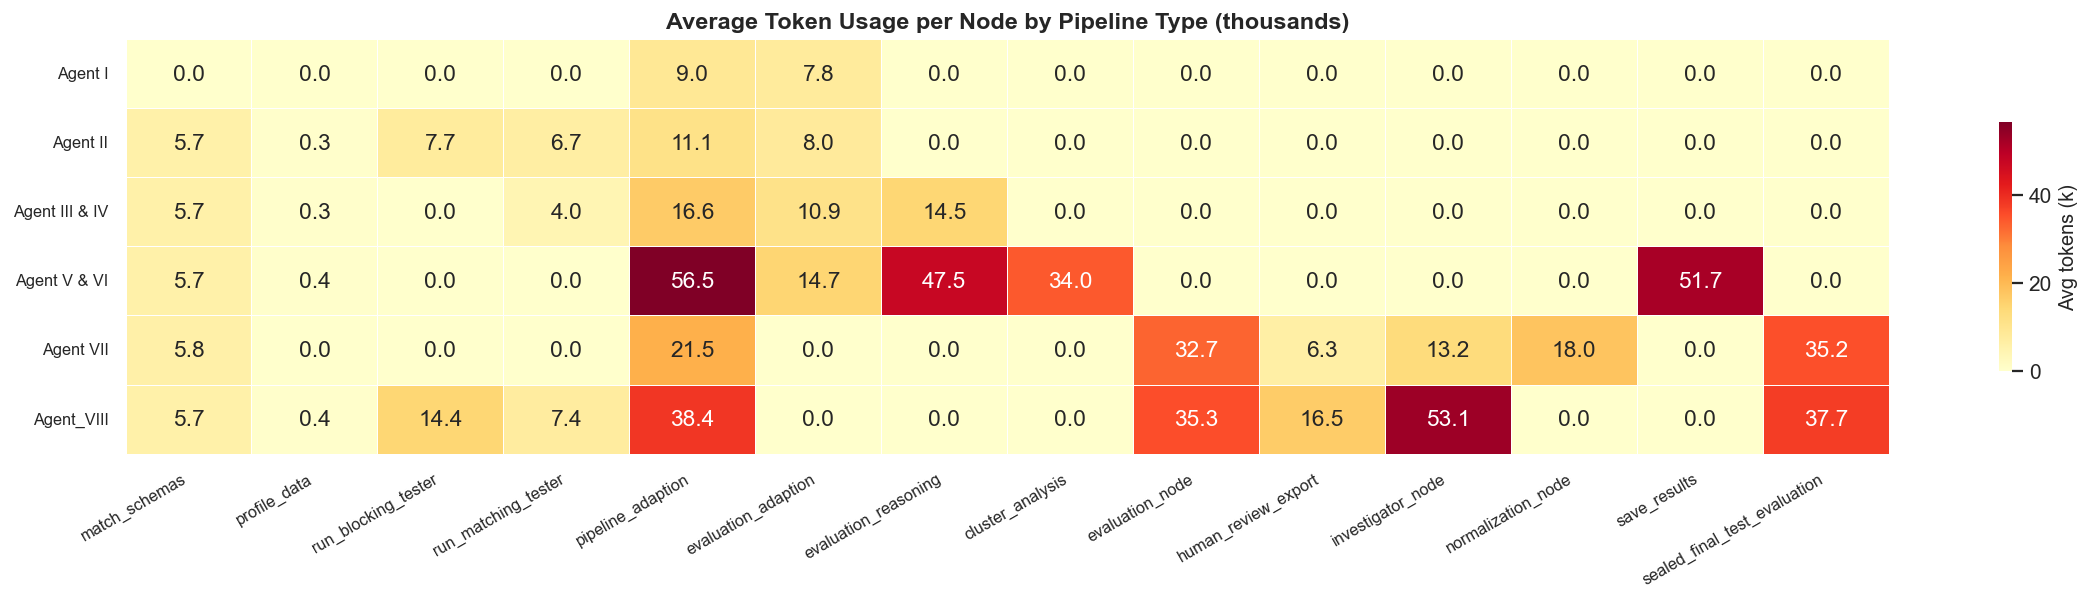

In [25]:
# ── 6e: Node visit profile by pipeline type ───────────────────────────────────
if not all_nodes.empty and pipeline_types:
    visit_pivot = (all_nodes.groupby(["pipeline_type","current_node"])
                            .size().reset_index(name="visits")
                            .pivot_table(index="pipeline_type", columns="current_node",
                                         values="visits", aggfunc="mean")
                            .fillna(0))
    cols_v = ([c for c in NODE_ORDER if c in visit_pivot.columns] +
              [c for c in visit_pivot.columns if c not in NODE_ORDER])
    visit_pivot = visit_pivot[cols_v]

    fig, ax = plt.subplots(figsize=(max(10, len(cols_v) * 1.3),
                                    max(3, len(visit_pivot) * 0.8)))
    sns.heatmap(visit_pivot, annot=True, fmt=".1f", cmap="Blues",
                linewidths=0.4, linecolor="white", ax=ax,
                cbar_kws={"label": "Avg visits per run", "shrink": 0.6})
    ax.set_title("Average Node Visit Count by Pipeline Type",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Token usage by pipeline type and node
    tok_pivot = (all_nodes[all_nodes["total_tokens"] > 0]
                 .groupby(["pipeline_type","current_node"])["total_tokens"]
                 .mean().reset_index()
                 .pivot_table(index="pipeline_type", columns="current_node",
                              values="total_tokens", aggfunc="mean")
                 .fillna(0))
    cols_t = ([c for c in NODE_ORDER if c in tok_pivot.columns] +
              [c for c in tok_pivot.columns if c not in NODE_ORDER])
    tok_pivot = tok_pivot[cols_t]

    if not tok_pivot.empty:
        fig, ax = plt.subplots(figsize=(max(10, len(cols_t) * 1.3),
                                        max(3, len(tok_pivot) * 0.8)))
        sns.heatmap(tok_pivot / 1000, annot=True, fmt=".1f", cmap="YlOrRd",
                    linewidths=0.4, linecolor="white", ax=ax,
                    cbar_kws={"label": "Avg tokens (k)", "shrink": 0.6})
        ax.set_title("Average Token Usage per Node by Pipeline Type (thousands)",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
        plt.tight_layout()
        plt.show()


In [26]:
# ── 6f: Token usage per use case ──────────────────────────────────────────────
if not all_nodes.empty and use_cases:
    tok_uc = all_nodes[all_nodes["total_tokens"] > 0].copy()

    if tok_uc.empty:
        print("No token data for use-case analysis.")
    else:

        # ── Summary table ──────────────────────────────────────────────────────
        tok_tbl = (tok_uc.groupby("use_case")
                         .agg(
                             total_tokens    =("total_tokens",     "sum"),
                             prompt_tokens   =("prompt_tokens",    "sum"),
                             completion_tokens=("completion_tokens","sum"),
                             runs            =("run_id",           "nunique"),
                         )
                         .reset_index())
        tok_tbl["avg_tokens_per_run"] = (tok_tbl["total_tokens"] / tok_tbl["runs"]).round(0)
        tok_tbl["prompt_%"]           = (tok_tbl["prompt_tokens"] / tok_tbl["total_tokens"] * 100).round(1)

        display(
            tok_tbl.style
            .background_gradient(subset=["total_tokens"],        cmap="YlOrRd")
            .background_gradient(subset=["avg_tokens_per_run"],  cmap="Blues")
            .format({
                "total_tokens":        "{:,.0f}",
                "prompt_tokens":       "{:,.0f}",
                "completion_tokens":   "{:,.0f}",
                "avg_tokens_per_run":  "{:,.0f}",
                "prompt_%":            "{:.1f}%",
            })
            .set_caption("Token Usage Summary by Use Case")
            .hide(axis="index")
        )

use_case,total_tokens,prompt_tokens,completion_tokens,runs,avg_tokens_per_run,prompt_%
Books,"2,103,029","1,843,161","259,868",8,"262,879",87.6%
Games,"2,070,867","1,864,097","206,770",8,"258,858",90.0%
Music,"2,243,837","1,964,811","279,026",8,"280,480",87.6%
Restaurants,"1,702,232","1,462,830","239,402",8,"212,779",85.9%


---
## 9 · Error & Retry Analysis

In [27]:
exceptions  = all_nodes[all_nodes["next_node"].str.contains("EXCEPTION", na=False)].copy()
failed_exec = all_nodes[all_nodes["output_summary"].str.contains("failed", case=False, na=False)].copy()

print(f"{'OK ' if exceptions.empty  else 'ERR'}  Exception transitions : {len(exceptions)}")
print(f"{'OK ' if failed_exec.empty else 'ERR'}  Failed execution nodes: {len(failed_exec)}")

if not exceptions.empty:
    print("\nException transitions:")
    display(
        exceptions[["label","node_index","current_node","next_node",
                    "duration_seconds","output_summary"]]
        .sort_values("label")
        .style.set_caption("Exception Transitions").hide(axis="index")
    )

retry_rows = []
for run_id, r in runs.items():
    ndf = r["nodes"]
    retry_rows.append({
        "Run":                       r["label"],
        "execute_pipeline visits":   int((ndf["current_node"] == "execute_pipeline").sum()),
        "execute_evaluation visits": int((ndf["current_node"] == "execute_evaluation").sum()),
        "pipeline_adaption visits":  int((ndf["current_node"] == "pipeline_adaption").sum()),
        "eval_reasoning visits":     int((ndf["current_node"] == "evaluation_reasoning").sum()),
        "exception transitions":     int(ndf["next_node"].str.contains("EXCEPTION", na=False).sum()),
    })

print("\nRetry & Iteration Counts:")
display(
    pd.DataFrame(retry_rows).style
    .background_gradient(subset=["execute_pipeline visits",
                                  "execute_evaluation visits",
                                  "pipeline_adaption visits"], cmap="YlOrRd")
    .background_gradient(subset=["exception transitions"], cmap="Reds")
    .set_caption("Retry & Iteration Counts per Run")
    .hide(axis="index")
)

OK   Exception transitions : 0
ERR  Failed execution nodes: 22

Retry & Iteration Counts:


Run,execute_pipeline visits,execute_evaluation visits,pipeline_adaption visits,eval_reasoning visits,exception transitions
Agent III (RB),5,3,5,2,0
Agent III (RB),6,3,6,2,0
Agent III (RB),4,3,4,2,0
Agent III (RB),3,3,3,2,0
Agent II (RB),6,3,6,0,0
Agent II (RB),3,3,3,0,0
Agent II (RB),4,3,4,0,0
Agent II (RB),5,3,5,0,0
Agent IV (ML),4,3,4,2,0
Agent IV (ML),5,3,5,2,0


---
## 10 · Use Case Analysis

Statistics and comparisons broken down by `use_case` — run distribution, accuracy, cost, duration, and pipeline-type mix.

In [28]:
# ── 11a: Use-case summary table ───────────────────────────────────────────────
if not all_eval.empty and use_cases:
    uc_rows = []
    for uc in use_cases:
        uc_runs   = {rid: r for rid, r in runs.items() if r["use_case"] == uc}
        accs      = []
        init_accs = []
        tokens_l  = []
        dur_l     = []
        iters_l   = []
        pts       = set()
        for r in uc_runs.values():
            ev = [e["accuracy_pct"] for e in r["eval_runs"] if e["accuracy_pct"] is not None]
            if ev:
                accs.append(ev[-1])
                init_accs.append(ev[0])
            tokens_l.append(int(r["nodes"]["total_tokens"].sum()))
            dur_l.append(r["time_summary"]["total_duration_s"] / 60)
            iters_l.append(len(r["eval_runs"]))
            pts.add(r["pipeline_type"])

        uc_rows.append({
            "Use Case":            uc,
            "Runs":                len(uc_runs),
            "Pipeline Types":      ", ".join(sorted(pts)),
            "Mean Init Acc (%)": round(float(np.mean(init_accs)), 2) if init_accs else None,
            "Mean Final Acc (%)": round(float(np.mean(accs)), 2)     if accs else None,
            "Best Final Acc (%)": round(float(np.max(accs)), 2)      if accs else None,
            "Mean Gain (pp)":    round(float(np.mean([a - b for a, b in zip(accs, init_accs)])), 2) if len(accs) > 0 and len(init_accs) == len(accs) else None,
            "Mean Iters":        round(float(np.mean(iters_l)), 1)   if iters_l else None,
            "Mean Tokens":       round(float(np.mean(tokens_l)))     if tokens_l else None,
            "Mean Duration (min)": round(float(np.mean(dur_l)), 1)   if dur_l else None,
        })

    uc_df = pd.DataFrame(uc_rows).sort_values("Mean Final Acc (%)", ascending=False)

    display(
        uc_df.style
        .background_gradient(subset=["Mean Final Acc (%)"], cmap="YlGn",  vmin=40, vmax=100)
        .background_gradient(subset=["Mean Gain (pp)"],     cmap="Blues")
        .background_gradient(subset=["Mean Tokens"],        cmap="Oranges")
        .background_gradient(subset=["Mean Duration (min)"],cmap="Purples")
        .format({
            "Mean Init Acc (%)": "{:.2f}",
            "Mean Final Acc (%)": "{:.2f}",
            "Best Final Acc (%)": "{:.2f}",
            "Mean Gain (pp)":    "{:+.2f}",
            "Mean Tokens":       "{:,.0f}",
        }, na_rep="—")
        .set_caption("Use Case Summary")
        .hide(axis="index")
        .set_table_styles([{"selector": "caption",
                            "props": [("font-size", "14px"),("font-weight","bold")]}])
    )
else:
    print("No use-case data available.")

Use Case,Runs,Pipeline Types,Mean Init Acc (%),Mean Final Acc (%),Best Final Acc (%),Mean Gain (pp),Mean Iters,Mean Tokens,Mean Duration (min)
Games,8,"Agent I, Agent II, Agent III & IV, Agent V & VI, Agent VII, Agent_VIII",59.93,78.95,88.57,+19.02,2.800000,"258,858",55.000000
Books,8,"Agent I, Agent II, Agent III & IV, Agent V & VI, Agent VII, Agent_VIII",63.28,63.73,91.25,+0.44,2.900000,"262,879",30.800000
Restaurants,8,"Agent I, Agent II, Agent III & IV, Agent V & VI, Agent VII, Agent_VIII",60.73,58.58,86.00,-2.15,2.800000,"212,779",19.300000
Music,8,"Agent I, Agent II, Agent III & IV, Agent V & VI, Agent VII, Agent_VIII",52.63,52.16,78.65,-0.48,3.000000,"280,480",21.600000


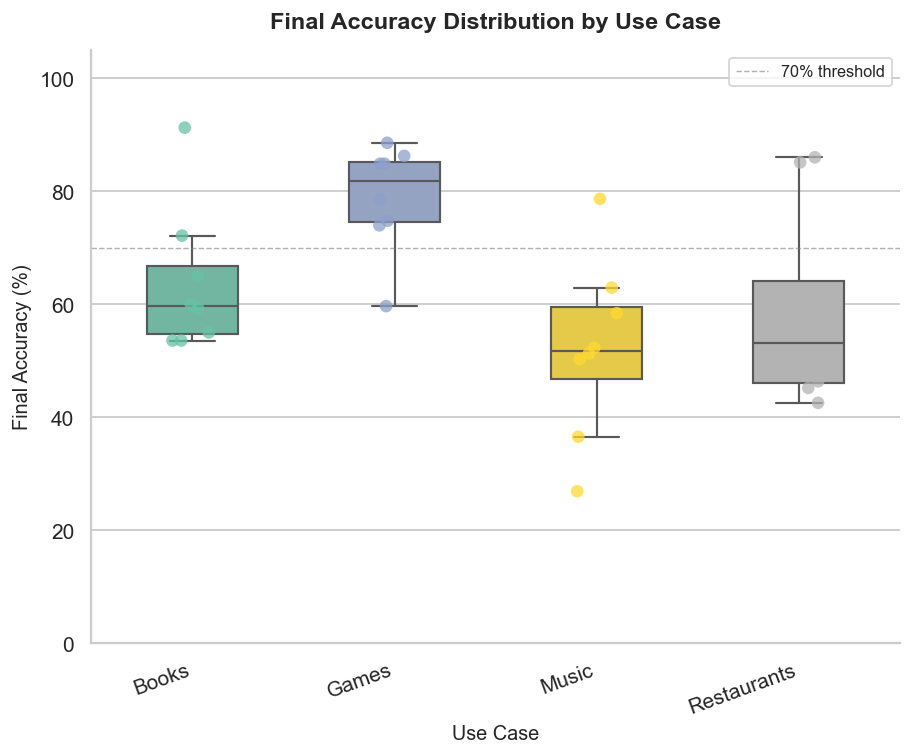

In [29]:
# ── 11b: Final accuracy distribution per use case (bar + individual runs) ─────
if not all_eval.empty and use_cases:
    final_acc_uc = (
        all_eval.sort_values("eval_iteration")
                .groupby("run_id").last().reset_index()
                [["run_id", "use_case", "pipeline_type", "accuracy_pct"]]
                .dropna(subset=["accuracy_pct"])
    )

    n_uc = len(use_cases)
    fig, ax = plt.subplots(figsize=(max(7, n_uc * 1.8), 6))
    sns.boxplot(data=final_acc_uc, x="use_case", y="accuracy_pct",
                palette=UC_COLOR, width=0.45, fliersize=0,
                linewidth=1.2, ax=ax, order=use_cases)
    sns.stripplot(data=final_acc_uc, x="use_case", y="accuracy_pct",
                  palette=UC_COLOR, jitter=True, size=7,
                  alpha=0.75, ax=ax, order=use_cases)
    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8, alpha=0.6,
               label="70% threshold")
    ax.set_title("Final Accuracy Distribution by Use Case",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Use Case")
    ax.set_ylabel("Final Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

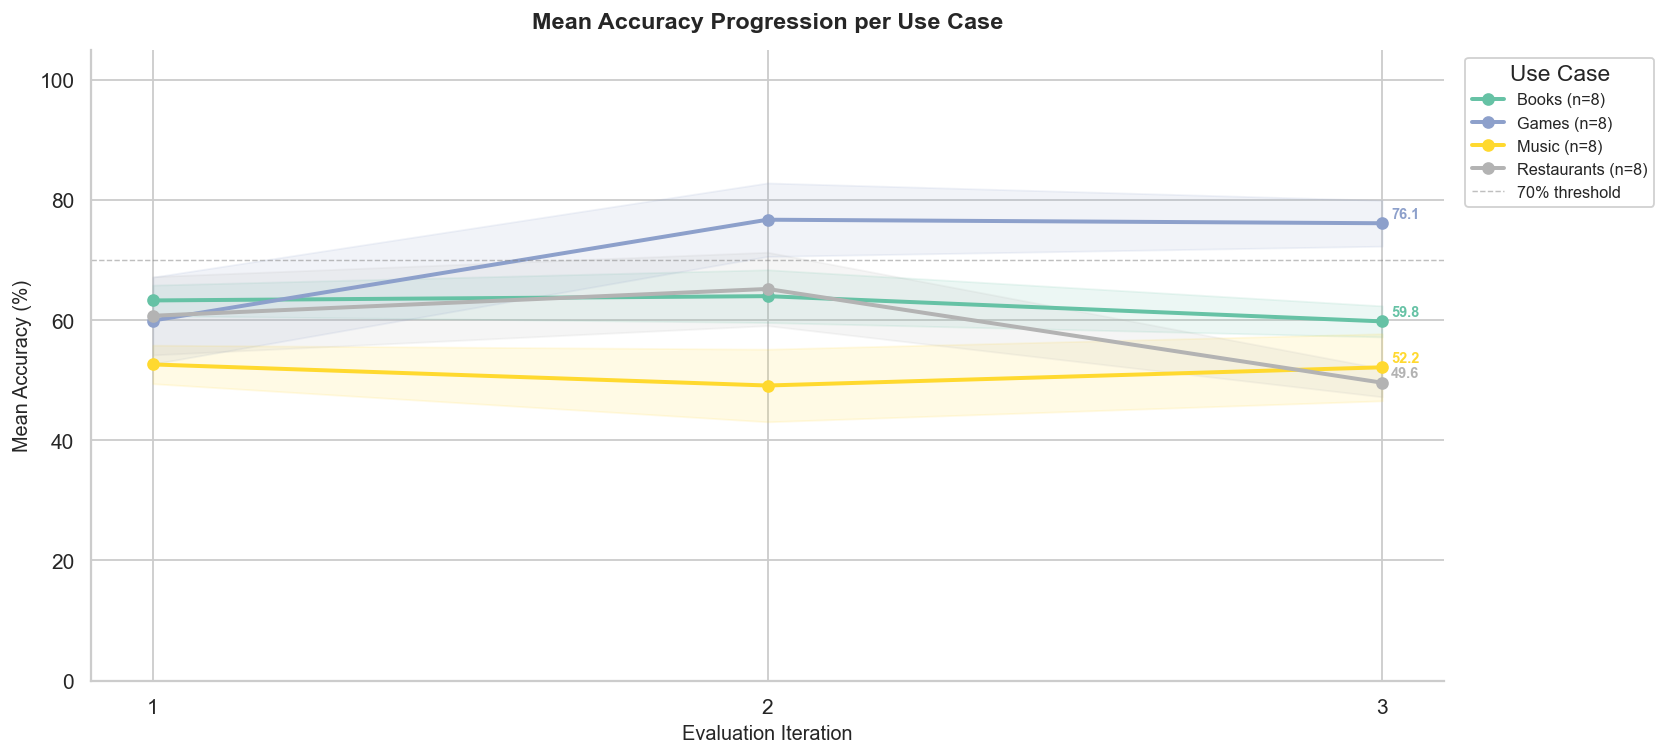

In [30]:
# ── 11c: Mean accuracy progression per use case ───────────────────────────────
if not all_eval.empty and len(use_cases) > 0:
    fig, ax = plt.subplots(figsize=(13, 6))

    for uc in use_cases:
        grp = all_eval[all_eval["use_case"] == uc]
        mean_acc = (
            grp.groupby("eval_iteration")["accuracy_pct"]
               .agg(mean="mean", sem=lambda x: x.std() / max(len(x)**0.5, 1))
               .reset_index()
        )
        color = UC_COLOR[uc]
        n_uc_runs = grp["run_id"].nunique()
        ax.plot(mean_acc["eval_iteration"], mean_acc["mean"],
                marker="o", linewidth=2.2, color=color,
                label=f"{uc} (n={n_uc_runs})")
        ax.fill_between(mean_acc["eval_iteration"],
                        mean_acc["mean"] - mean_acc["sem"],
                        mean_acc["mean"] + mean_acc["sem"],
                        color=color, alpha=0.12)
        last = mean_acc.iloc[-1]
        ax.annotate(f"{last['mean']:.1f}",
                    xy=(last["eval_iteration"], last["mean"]),
                    xytext=(5, 3), textcoords="offset points",
                    fontsize=8, color=color, fontweight="bold")

    ax.axhline(70, color="gray", linestyle="--", linewidth=0.8,
               alpha=0.5, label="70% threshold")
    ax.set_title("Mean Accuracy Progression per Use Case",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Evaluation Iteration")
    ax.set_ylabel("Mean Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Use Case", fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    plt.show()

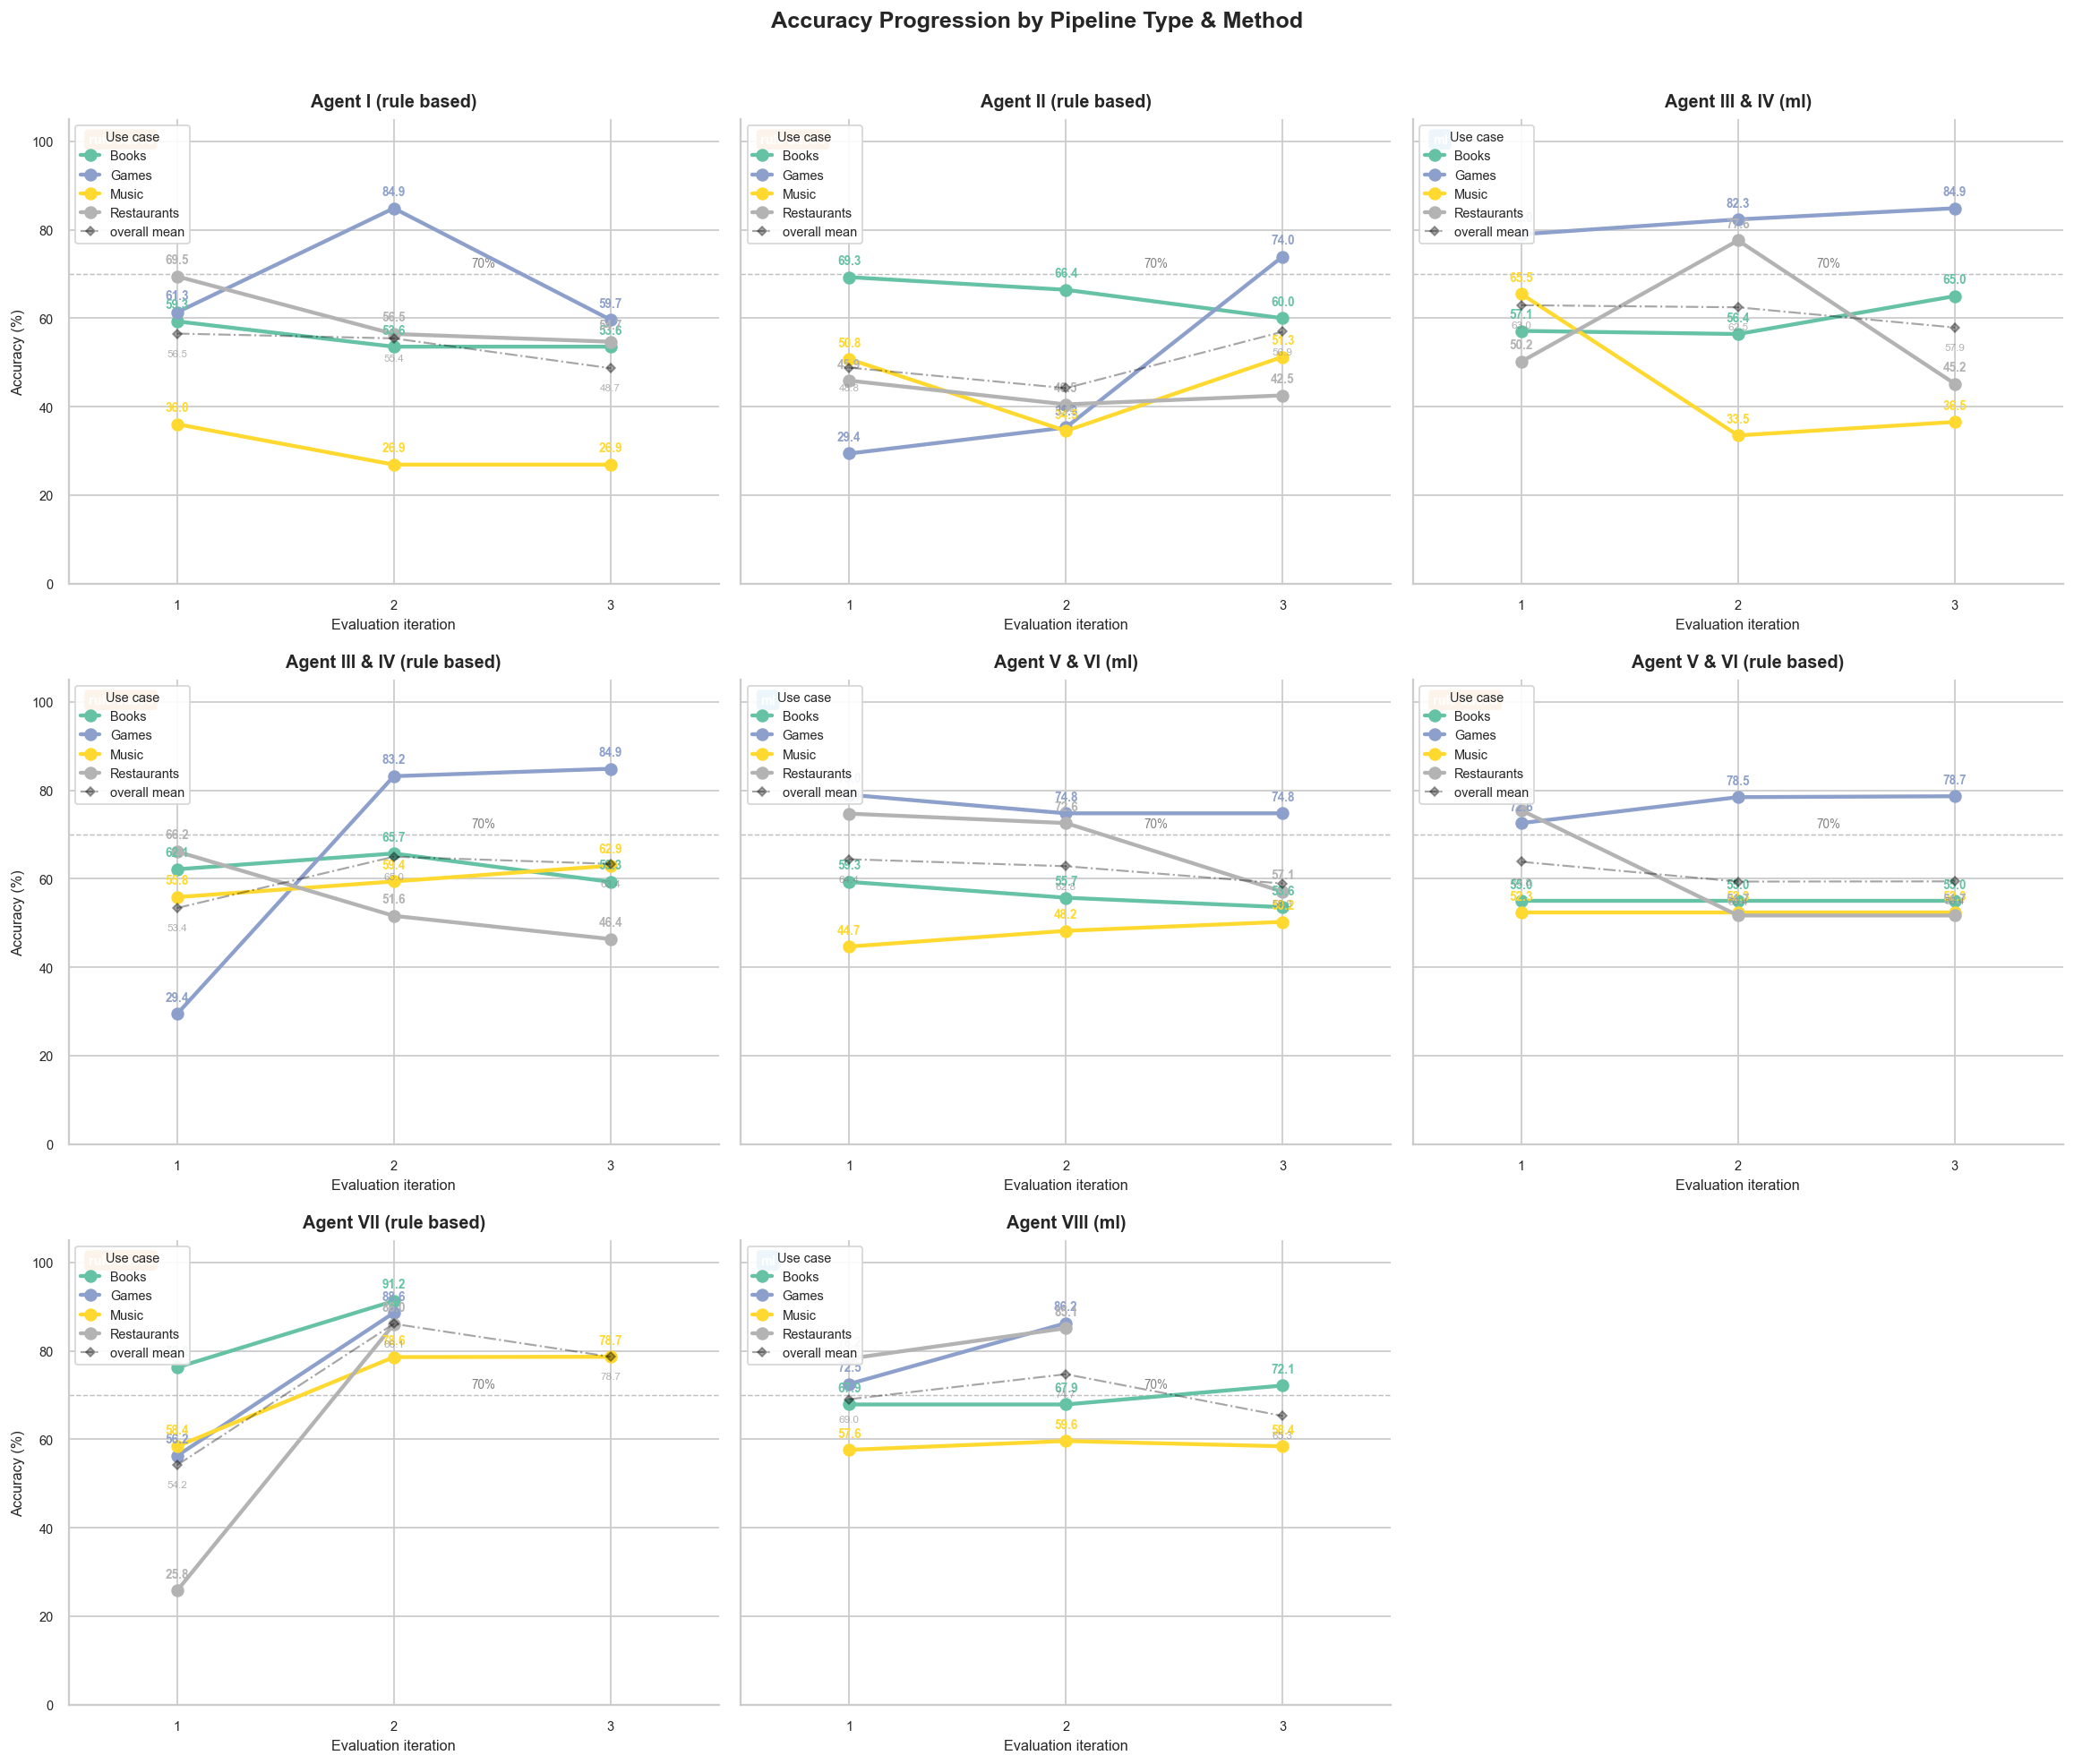

In [31]:
# ── 11c: Accuracy progression — one panel per pipeline_type × method ──────────
if not all_eval.empty and len(pipeline_types) > 0:

    def get_title(pt, method):
        return (pt.replace("_", " ") + f" ({method.replace('_', ' ')})")

    all_eval["method"]    = all_eval["method"]
    all_eval["pt_method"] = all_eval["pipeline_type"] + "_" + all_eval["method"]

    sorted_pts = sorted(all_eval["pt_method"].unique(),
                        key=lambda x: (x.replace("_ml", "").replace("_rule_based", ""), x))

    n_panels = len(sorted_pts)
    n_cols   = 3
    n_rows   = (n_panels + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6 * n_cols, 5 * n_rows),
                             sharey=True, squeeze=False)
    axes_flat = axes.flatten()

    for idx, pt_method in enumerate(sorted_pts):
        ax     = axes_flat[idx]
        grp    = all_eval[all_eval["pt_method"] == pt_method]
        method = grp["method"].iloc[0]
        pt     = grp["pipeline_type"].iloc[0]
        title  = get_title(pt, method)

        for uc, uc_grp in grp.groupby("use_case"):
            color  = UC_COLOR[uc]
            n_runs = uc_grp["run_id"].nunique()

            # Individual runs — thin & faded when more than one per use case
            if n_runs > 1:
                for run_id, run_grp in uc_grp.groupby("run_id"):
                    run_s = run_grp.sort_values("eval_iteration")
                    ax.plot(run_s["eval_iteration"], run_s["accuracy_pct"],
                            color=color, linewidth=1.0, marker="o",
                            markersize=4, alpha=0.3, zorder=2,
                            linestyle="--")

            # Mean per use case — bold line
            mean_acc = (
                uc_grp.groupby("eval_iteration")["accuracy_pct"]
                      .mean().reset_index()
            )
            ax.plot(mean_acc["eval_iteration"], mean_acc["accuracy_pct"],
                    color=color, linewidth=2.4, marker="o",
                    markersize=7, alpha=1.0, zorder=4,
                    label=f"{uc}" + (f" (n={n_runs})" if n_runs > 1 else ""))

            # Value labels on use-case mean markers
            for _, row in mean_acc.iterrows():
                ax.annotate(
                    f"{row['accuracy_pct']:.1f}",
                    xy=(row["eval_iteration"], row["accuracy_pct"]),
                    xytext=(0, 8), textcoords="offset points",
                    fontsize=7.5, color=color, ha="center",
                    fontweight="bold", zorder=5,
                )

        # -- Overall mean across ALL use cases for this panel ─────────────────
        overall_mean = (
            grp.groupby("eval_iteration")["accuracy_pct"]
               .mean().reset_index()
        )
        ax.plot(overall_mean["eval_iteration"], overall_mean["accuracy_pct"],
        color="black", linewidth=1.2, marker="D",
        markersize=4, linestyle="-.", alpha=0.35, zorder=6,
        label="overall mean")

        # Value labels on overall mean markers
        for _, row in overall_mean.iterrows():
            ax.annotate(
                f"{row['accuracy_pct']:.1f}",
                xy=(row["eval_iteration"], row["accuracy_pct"]),
                xytext=(0, -14), textcoords="offset points",
                fontsize=6.5, color="gray", ha="center",
                alpha=0.6, zorder=7,
            )

        # Method badge
        method_color = "#3498db" if method == "ml" else "#e67e22"
        ax.text(0.03, 0.97, method.replace("_", " "),
                transform=ax.transAxes, fontsize=8, fontweight="bold",
                va="top", ha="left", color="white",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=method_color,
                          edgecolor="none", alpha=0.85))

        ax.axhline(70, color="gray", linestyle="--",
                   linewidth=0.8, alpha=0.5, zorder=1)
        ax.text(0.62, 71, "70%", fontsize=7.5, color="gray",
                va="bottom", transform=ax.get_yaxis_transform())

        ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
        ax.set_xlabel("Evaluation iteration", fontsize=9)
        ax.set_ylabel("Accuracy (%)" if idx % n_cols == 0 else "", fontsize=9)
        ax.set_ylim(0, 105)
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(["1", "2", "3"])
        ax.set_xlim(0.5, 3.5)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=8)
        ax.legend(title="Use case", fontsize=8, title_fontsize=8,
                  loc="upper left", framealpha=0.9,
                  edgecolor="lightgray", handlelength=1.5)

    for ax in axes_flat[n_panels:]:
        ax.set_visible(False)

    fig.suptitle("Accuracy Progression by Pipeline Type & Method",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

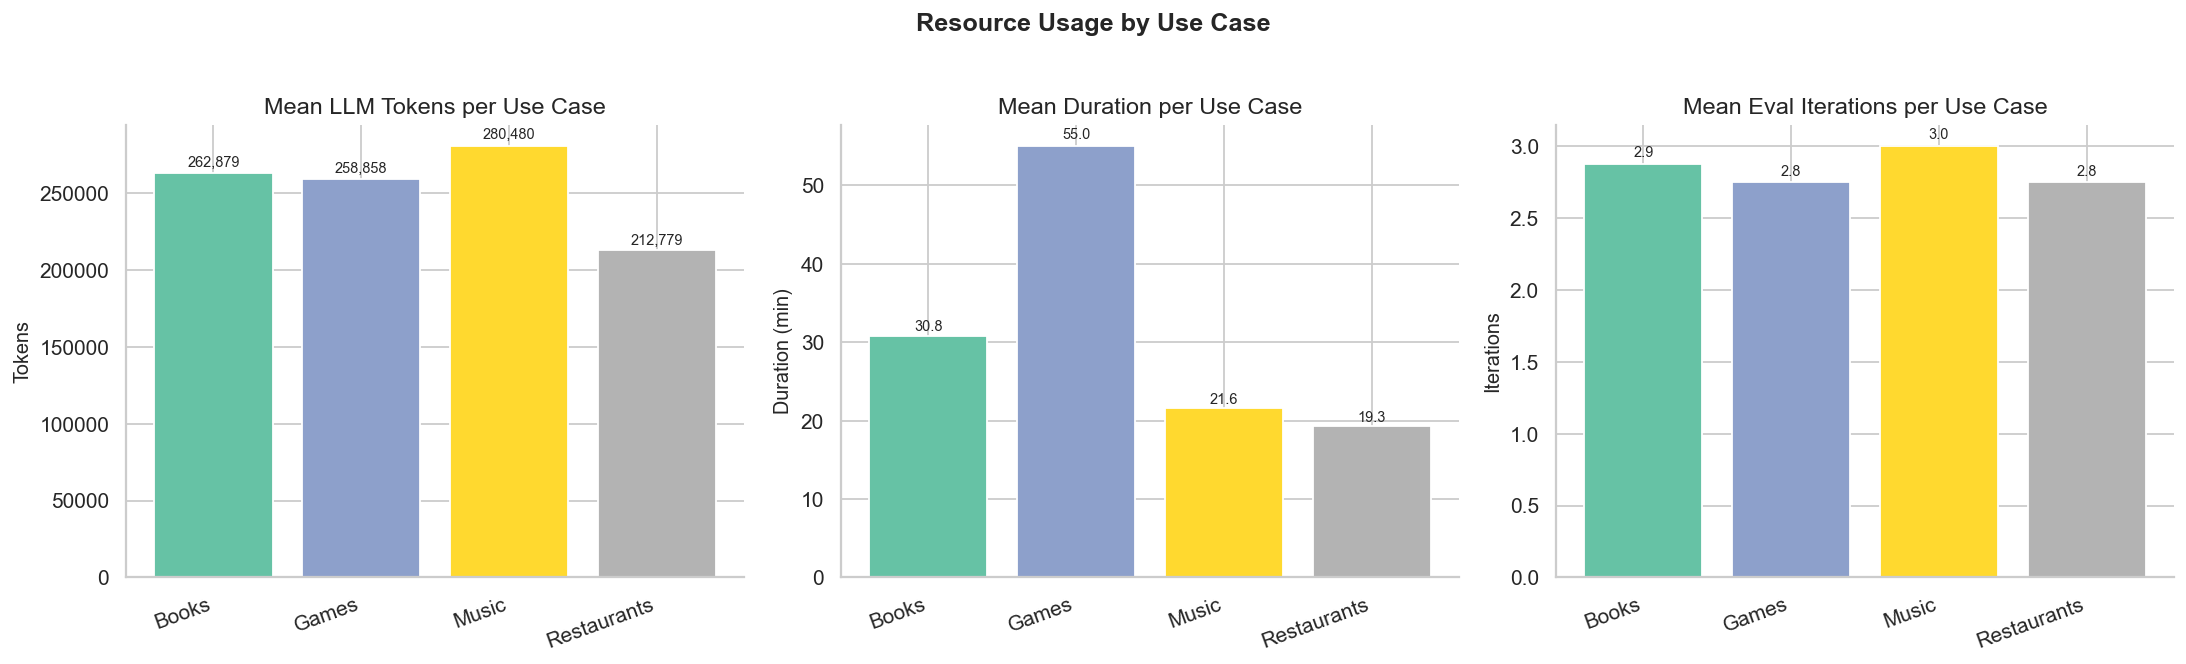

In [32]:
# ── 11d: Token & duration comparison across use cases ────────────────────────
if not all_eval.empty and use_cases:
    uc_eff_rows = []
    for rid, r in runs.items():
        ev = [e["accuracy_pct"] for e in r["eval_runs"] if e["accuracy_pct"] is not None]
        uc_eff_rows.append({
            "use_case":      r["use_case"],
            "pipeline_type": r["pipeline_type"],
            "final_acc":     ev[-1] if ev else None,
            "total_tokens":  int(r["nodes"]["total_tokens"].sum()),
            "duration_min":  r["time_summary"]["total_duration_s"] / 60,
            "n_iters":       len(r["eval_runs"]),
        })
    df_uc_eff = pd.DataFrame(uc_eff_rows)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Tokens per use case
    ax = axes[0]
    uc_tok = df_uc_eff.groupby("use_case")["total_tokens"].mean().reindex(use_cases)
    bars = ax.bar(use_cases, uc_tok.values,
                  color=[UC_COLOR[u] for u in use_cases], edgecolor="white")
    for bar, val in zip(bars, uc_tok.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=8)
    ax.set_title("Mean LLM Tokens per Use Case")
    ax.set_ylabel("Tokens")
    ax.set_xlabel("")
    ax.spines[["top", "right"]].set_visible(False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

    # Duration per use case
    ax2 = axes[1]
    uc_dur = df_uc_eff.groupby("use_case")["duration_min"].mean().reindex(use_cases)
    bars2 = ax2.bar(use_cases, uc_dur.values,
                    color=[UC_COLOR[u] for u in use_cases], edgecolor="white")
    for bar, val in zip(bars2, uc_dur.values):
        ax2.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=8)
    ax2.set_title("Mean Duration per Use Case")
    ax2.set_ylabel("Duration (min)")
    ax2.set_xlabel("")
    ax2.spines[["top", "right"]].set_visible(False)
    plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")

    # Iterations per use case
    ax3 = axes[2]
    uc_iters = df_uc_eff.groupby("use_case")["n_iters"].mean().reindex(use_cases)
    bars3 = ax3.bar(use_cases, uc_iters.values,
                    color=[UC_COLOR[u] for u in use_cases], edgecolor="white")
    for bar, val in zip(bars3, uc_iters.values):
        ax3.text(bar.get_x() + bar.get_width() / 2, val * 1.01,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=8)
    ax3.set_title("Mean Eval Iterations per Use Case")
    ax3.set_ylabel("Iterations")
    ax3.set_xlabel("")
    ax3.spines[["top", "right"]].set_visible(False)
    plt.setp(ax3.get_xticklabels(), rotation=20, ha="right")

    plt.suptitle("Resource Usage by Use Case", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()